# EDA

В этом ноутбуке проводится первичный анализ данных для поиска новых фич и закономерностей

## Импорт библиотек и загрузка данных

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
COLOR_HUMAN = '#2b5c8f'   
COLOR_BOT = '#d9534f'    

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv', parse_dates=['event_ts'])

print(f"train shape:  {train.shape}")
print(f"test shape:   {test.shape}")
print(f"events shape: {events.shape}")

train shape:  (11091, 5)
test shape:   (4909, 4)
events shape: (328905, 14)


## Проверим на дупликаты

In [ ]:
dfs = {"train": train, "test": test, "events": events}

for name, df in dfs.items():
    duplicates_mask = df.duplicated()
    num_duplicates = duplicates_mask.sum()
    pct_duplicates = (num_duplicates / len(df)) * 100

    print(
        f"{name:<7} | Дубликатов: {num_duplicates:>8,} | ({pct_duplicates:.4f}%)"
    )

train   | Дубликатов:        0 | (0.0000%)
test    | Дубликатов:        0 | (0.0000%)
events  | Дубликатов:    4,863 | (1.4785%)


Как видим в events присутствую дупликаты, которые в дальнейшем надо удалить, чтобы не мешали при построении новых признаков

## Проверка на пропуски

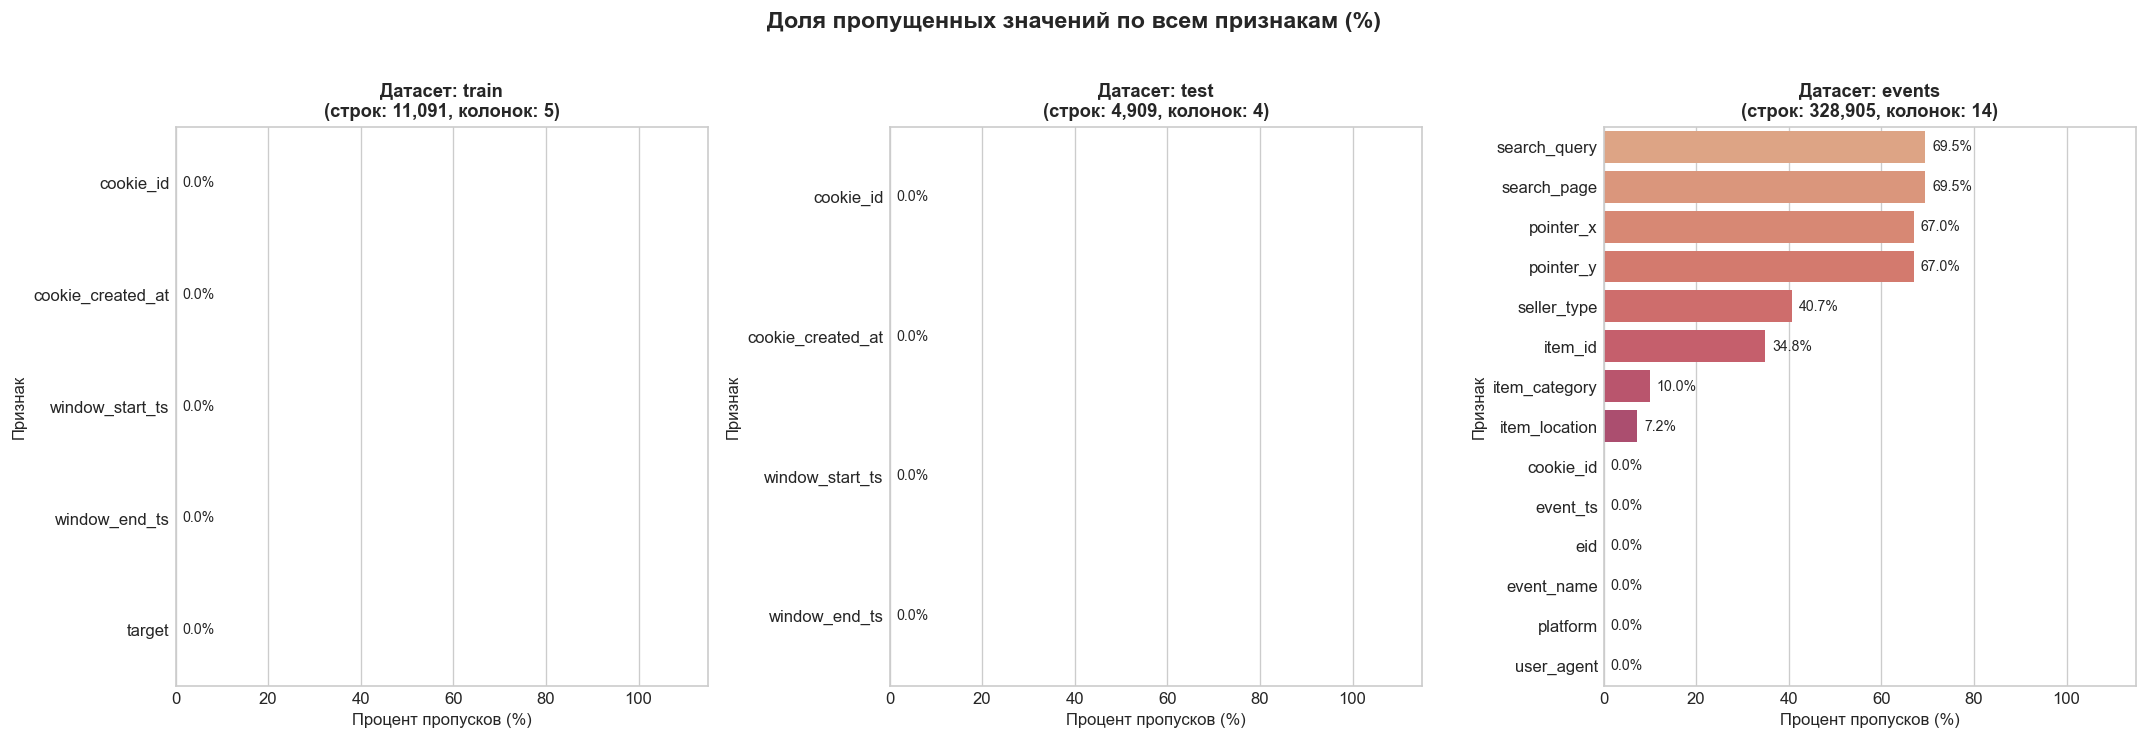

In [ ]:
datasets = {"train": train, "test": test, "events": events}
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
palettes = ["mako", "viridis", "flare"]

for ax, (name, df), palette in zip(axes, datasets.items(), palettes):
    miss_df = (df.isna().mean() * 100).sort_values(ascending=False).reset_index()
    miss_df.columns = ["feature", "missing_pct"]

    sns.barplot(
        data=miss_df,
        x="missing_pct",
        y="feature",
        ax=ax,
        palette=palette,
        hue="feature",
        legend=False,
    )

    ax.set_title(
        f"Датасет: {name}\n(строк: {len(df):,}, колонок: {df.shape[1]})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Процент пропусков (%)")
    ax.set_ylabel("Признак")
    ax.set_xlim(0, 115) 

    for p in ax.patches:
        w = p.get_width()
        ax.annotate(
            f"{w:.1f}%",
            (w + 1.5, p.get_y() + p.get_height() / 2.0),
            va="center",
            fontsize=8.5,
        )

plt.suptitle(
    "Доля пропущенных значений по всем признакам (%)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

Train и Test не содержит пропуски в отличии от events, которые имеет многочисленные пропуски по некоторым признакам в дальнейшем надо подумать, что с ними сделать, но напрмиер некоторые реализации деревьев работают нативно с пропусками. Теперь поподробнее посмотрим на род пропусков может есть закономерность от других признаков

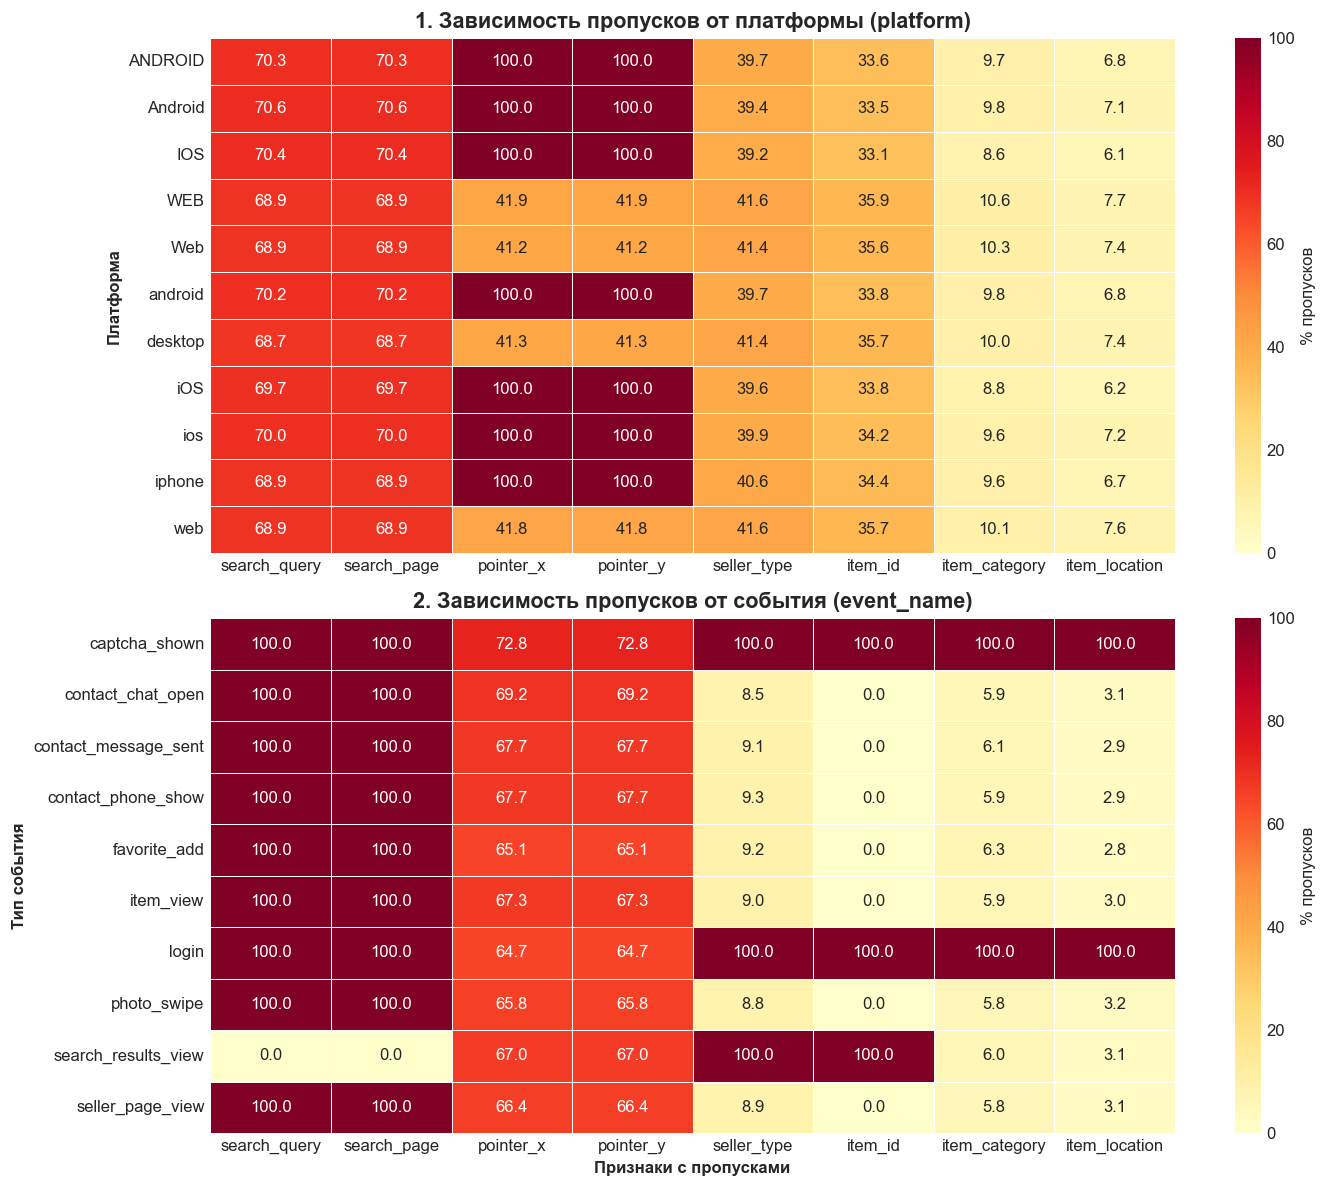

In [ ]:
cols_with_nans = [
    "search_query",
    "search_page",
    "pointer_x",
    "pointer_y",
    "seller_type",
    "item_id",
    "item_category",
    "item_location",
]

platform_missing = events.groupby("platform")[cols_with_nans].apply(
    lambda x: (x.isna().mean() * 100)
)

event_missing = events.groupby("event_name")[cols_with_nans].apply(
    lambda x: (x.isna().mean() * 100)
)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.heatmap(
    platform_missing,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% пропусков"},
    ax=axes[0],
    linewidths=0.5,
)
axes[0].set_title(
    "1. Зависимость пропусков от платформы (platform)",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Платформа", fontweight="bold")

# Карта 2: Событие vs Пропуски
sns.heatmap(
    event_missing,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% пропусков"},
    ax=axes[1],
    linewidths=0.5,
)
axes[1].set_title(
    "2. Зависимость пропусков от события (event_name)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Признаки с пропусками", fontweight="bold")
axes[1].set_ylabel("Тип события", fontweight="bold")

plt.tight_layout()
plt.show()

Тут важно замечания. Во-первых платформы сломаны и их надо привести к единому написанию для дальнейшой стабильности и удобства. Во-вторых как и предполагалось некоторые зависимости, например, координаты клика имеют только десктопные устройства и входы через браузер, что и логично так как на телефоне нет мыши. Так же search_query и search_page присутствуют только при событии search_result_view, также можно и аналогично объяснить другие пропуски. В дальнейшем можно создать признаки на основе этих пропусков

## Посмотрим на таргет

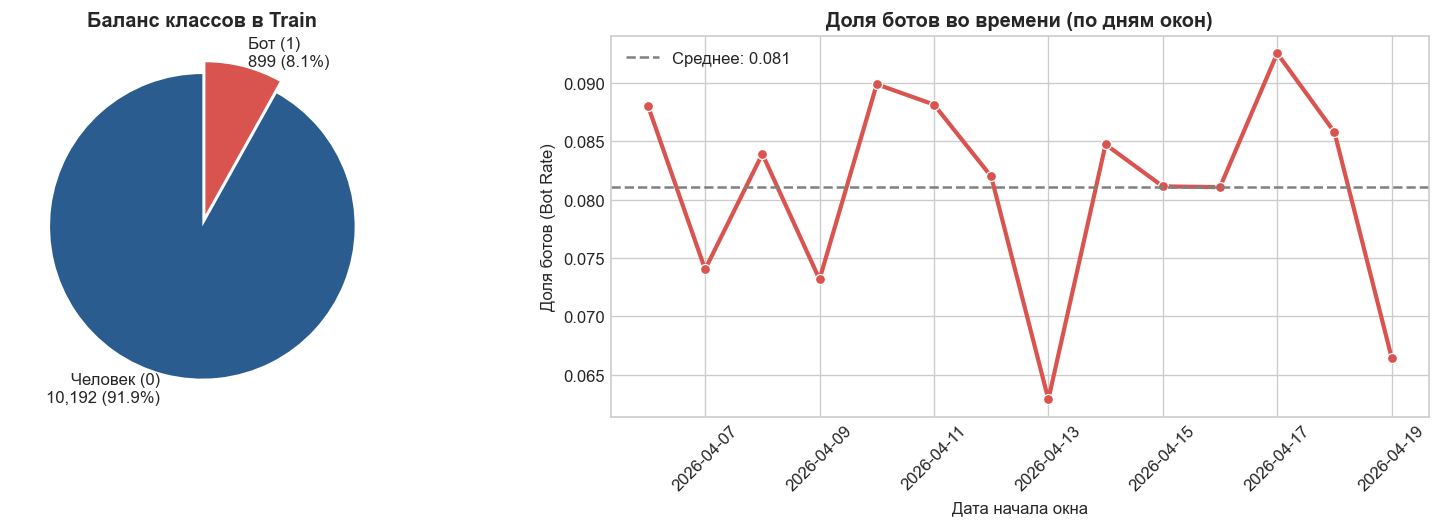

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))


target_counts = train.target.value_counts()
axes[0].pie(
    target_counts, 
    labels=[f"Человек (0)\n{target_counts[0]:,} ({target_counts[0]/len(train):.1%})",
            f"Бот (1)\n{target_counts[1]:,} ({target_counts[1]/len(train):.1%})"],
    colors=[COLOR_HUMAN, COLOR_BOT],
    autopct='',
    startangle=90,
    explode=(0, 0.08)
)
axes[0].set_title("Баланс классов в Train", fontweight='bold')

daily_bot_rate = train.groupby(train.window_start_ts.dt.date)['target'].agg(['count', 'mean']).reset_index()
sns.lineplot(data=daily_bot_rate, x='window_start_ts', y='mean', ax=axes[1], marker='o', color=COLOR_BOT, linewidth=2.5)
axes[1].axhline(train.target.mean(), color='gray', linestyle='--', label=f'Среднее: {train.target.mean():.3f}')
axes[1].set_title("Доля ботов во времени (по дням окон)", fontweight='bold')
axes[1].set_ylabel("Доля ботов (Bot Rate)")
axes[1].set_xlabel("Дата начала окна")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

В данных присутствует сильный дисбаланс класса, поэтому в дальнейшем при обучении попробовать для модели поставить балансировку класса, а так же при валидации использовать стратификацию для получения естественных результатов. Если смотреть на 2 график, то колебания присутствуют, но я бы не сказал, что это критично

## Посмотрим на временные параметры

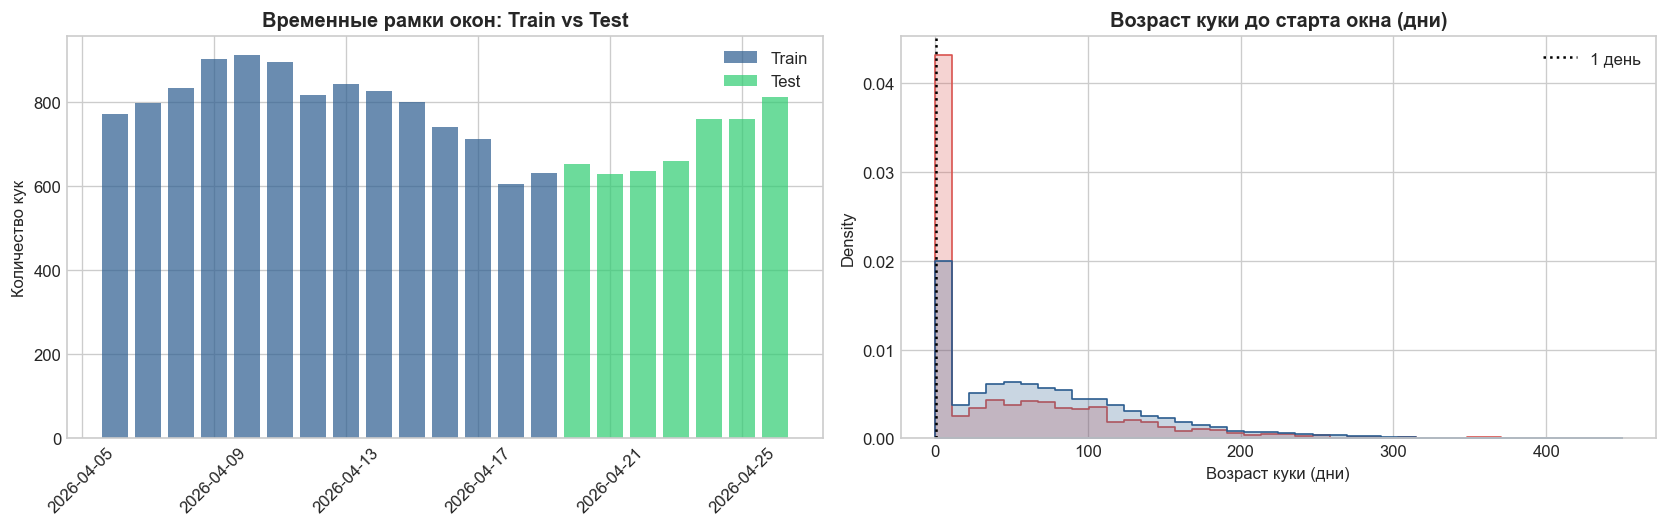

In [ ]:
train['cookie_age_days'] = (train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 86400.0
test['cookie_age_days'] = (test.window_start_ts - test.cookie_created_at).dt.total_seconds() / 86400.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

train_dates = train.window_start_ts.dt.date.value_counts().sort_index()
test_dates = test.window_start_ts.dt.date.value_counts().sort_index()
axes[0].bar(train_dates.index, train_dates.values, label='Train', color=COLOR_HUMAN, alpha=0.7)
axes[0].bar(test_dates.index, test_dates.values, label='Test', color='#2ecc71', alpha=0.7)
axes[0].set_title("Временные рамки окон: Train vs Test", fontweight='bold')
axes[0].set_ylabel("Количество кук")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

train['Class'] = train.target.map({0: 'Человек', 1: 'Бот'})
sns.histplot(
    data=train, 
    x='cookie_age_days', 
    hue='Class', 
    hue_order=["Человек", "Бот"],
    bins=40, 
    element='step', 
    stat='density', 
    common_norm=False, 
    ax=axes[1],
    palette=[COLOR_HUMAN, COLOR_BOT]
)
axes[1].set_title("Возраст куки до старта окна (дни)", fontweight='bold')
axes[1].set_xlabel("Возраст куки (дни)")
axes[1].axvline(1.0, color='black', linestyle=':', label='1 день')
axes[1].legend()

plt.tight_layout()
plt.show()

Пересечение train с test нет, но для валидации надо также учитывать временной промежуток. По 2 графику можно понять, что большинство кук были недавние, как и человек, так и ботов, но признаки на основе возраста куки могут помочь найти бота

In [ ]:
# Фильтруем события по условию задачи
ev_tr = events.merge(train[['cookie_id', 'window_start_ts', 'window_end_ts', 'target']], on='cookie_id', how='inner')
ev_tr = ev_tr[(ev_tr.event_ts >= ev_tr.window_start_ts) & (ev_tr.event_ts < ev_tr.window_end_ts)].copy()

# Сортировка для таймингов
ev_tr = ev_tr.sort_values(['cookie_id', 'event_ts'])
ev_tr['dt'] = ev_tr.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()
ev_tr['platform_clean'] = ev_tr['platform'].astype(str).str.lower()
ev_tr['Class'] = ev_tr['target'].map({0: 'Человек', 1: 'Бот'})

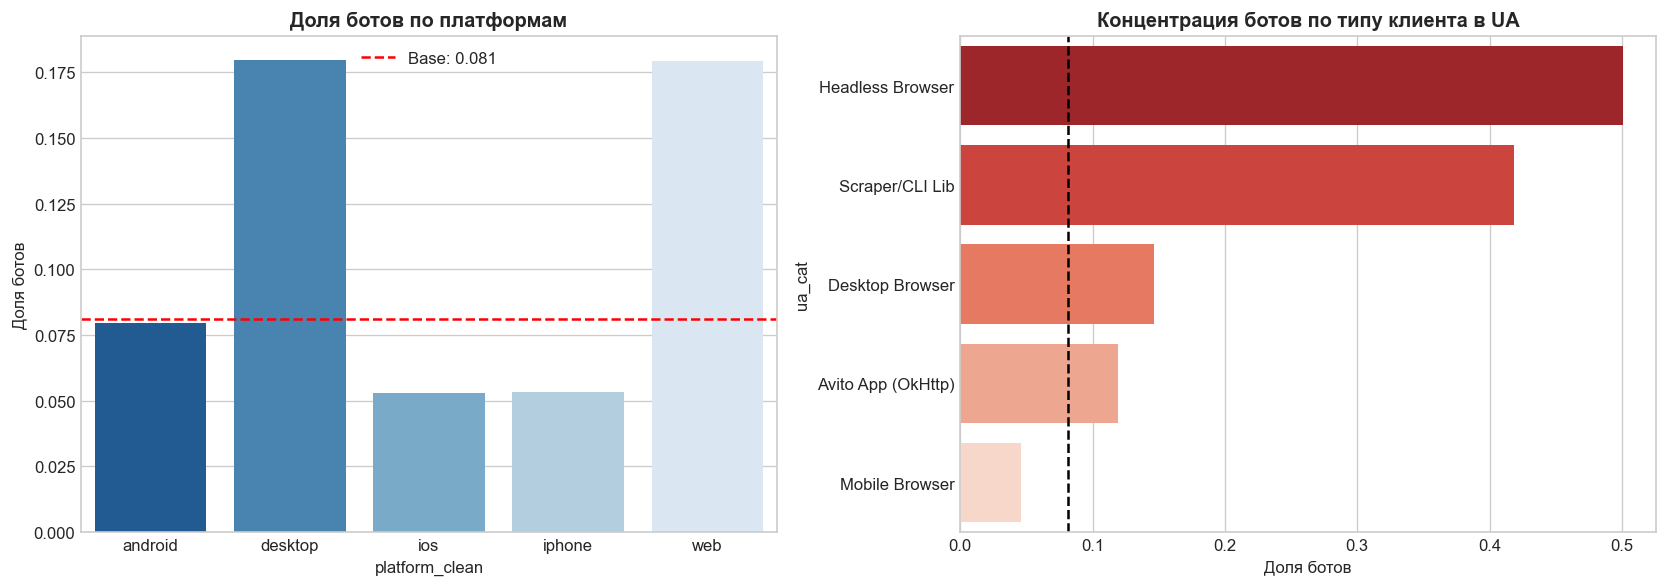

In [ ]:
def categorize_ua(ua):
    ua = str(ua).lower()
    if any(k in ua for k in ['scrapy', 'curl', 'requests', 'urllib', 'http-client', 'fetch', 'python']):
        return 'Scraper/CLI Lib'
    if 'headless' in ua:
        return 'Headless Browser'
    if 'okhttp' in ua or 'avito/' in ua:
        return 'Avito App (OkHttp)'
    if any(k in ua for k in ['iphone', 'mobile safari', 'android.*chrome']):
        return 'Mobile Browser'
    return 'Desktop Browser'

ev_tr['ua_cat'] = ev_tr['user_agent'].apply(categorize_ua)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plat_bot = ev_tr.groupby('platform_clean')['target'].agg(['count', 'mean']).reset_index()
sns.barplot(data=plat_bot, x='platform_clean', y='mean', ax=axes[0], palette='Blues_r')
axes[0].axhline(train.target.mean(), color='red', linestyle='--', label=f'Base: {train.target.mean():.3f}')
axes[0].set_title("Доля ботов по платформам", fontweight='bold')
axes[0].set_ylabel("Доля ботов")
axes[0].legend()

ua_bot = ev_tr.groupby('ua_cat')['target'].agg(['count', 'mean']).reset_index()
ua_bot = ua_bot.sort_values('mean', ascending=False)
sns.barplot(data=ua_bot, x='mean', y='ua_cat', ax=axes[1], palette='Reds_r')
axes[1].axvline(train.target.mean(), color='black', linestyle='--')
axes[1].set_title("Концентрация ботов по типу клиента в UA", fontweight='bold')
axes[1].set_xlabel("Доля ботов")

plt.tight_layout()
plt.show()

По 1 графику заметим, что боты преобладают на компах, а по 2 графику тоже брраузер, но при этом user_agent также содержит либы из языков программирования (например python-requests), что может характеризовать ботов, поэтому из user_agent можно достать новые фичи.

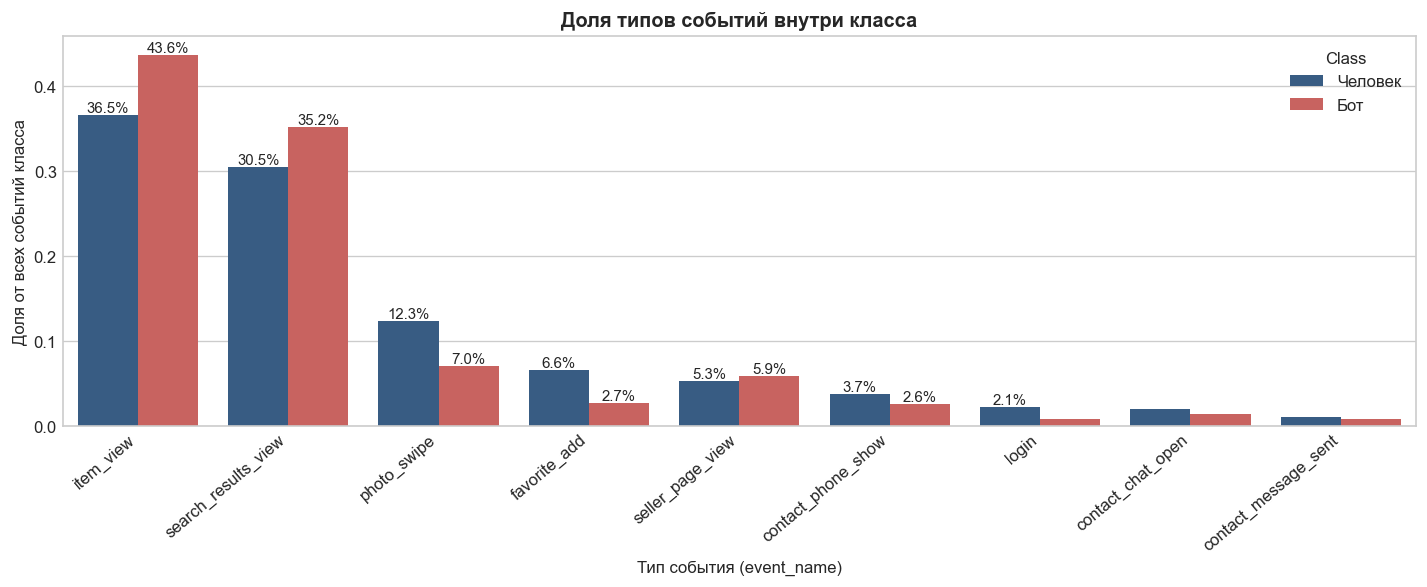

In [ ]:
event_stats = ev_tr.groupby(['Class', 'event_name']).size().reset_index(name='count')
event_stats['ratio'] = event_stats['count'] / event_stats.groupby('Class')['count'].transform('sum')

plt.figure(figsize=(12, 5))
order = ev_tr['event_name'].value_counts().index

ax = sns.barplot(data=event_stats, x='event_name', y='ratio', hue='Class',hue_order=["Человек", "Бот"],  order=order, palette=[COLOR_HUMAN, COLOR_BOT])
plt.title("Доля типов событий внутри класса", fontsize=12, fontweight='bold')
plt.xlabel("Тип события (event_name)")
plt.ylabel("Доля от всех событий класса")
plt.xticks(rotation=40, ha='right')

for p in ax.patches:
    h = p.get_height()
    if h > 0.02:
        ax.annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Как и ожидалось, что пользователь в большинстве смотрит товары, если смотреть на бота, то они выполняют в том же объеме как и человек, но просмотр у них больше, что может их выдать

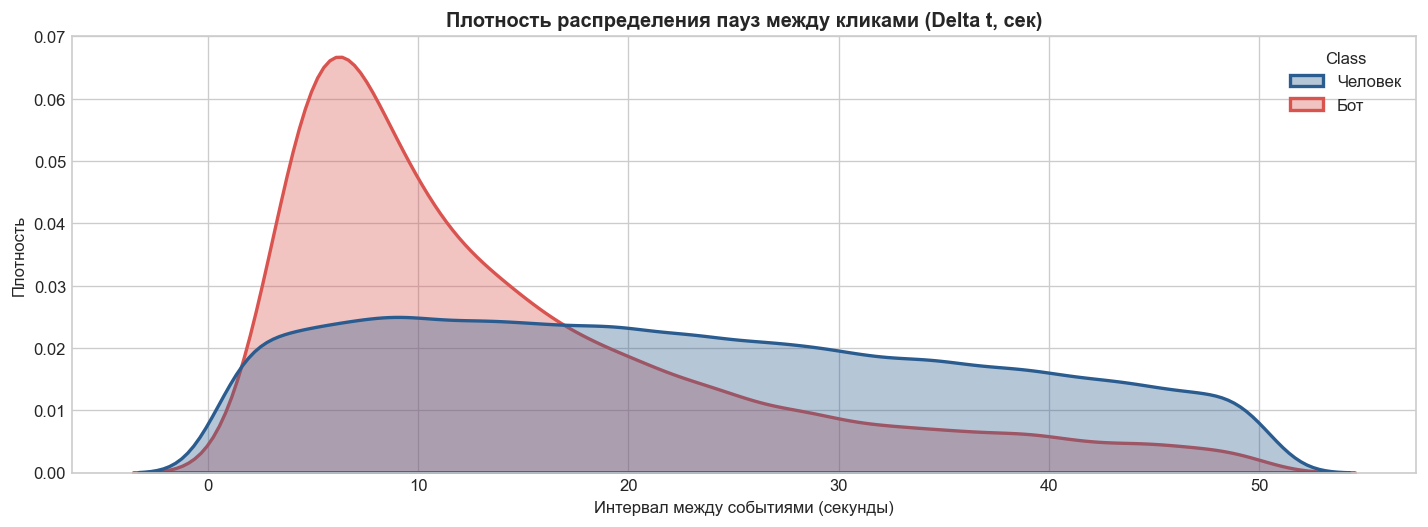

In [ ]:
plt.figure(figsize=(12, 4.5))

dt_sample = ev_tr[(ev_tr.dt > 0) & (ev_tr.dt <= 50)].copy()
sns.kdeplot(
    data=dt_sample, 
    x='dt', 
    hue='Class', 
    hue_order=["Человек", "Бот"],
    common_norm=False, 
    fill=True, 
    alpha=0.35, 
    linewidth=2,

    palette=[COLOR_HUMAN, COLOR_BOT]
)

plt.title("Плотность распределения пауз между кликами (Delta t, сек)", fontsize=12, fontweight='bold')
plt.xlabel("Интервал между событиями (секунды)")
plt.ylabel("Плотность")
plt.tight_layout()
plt.show()

Заметим, что боты обычно делают события быстро, а человек равномерно, поэтому приззнаки на оснве этого должны помочь

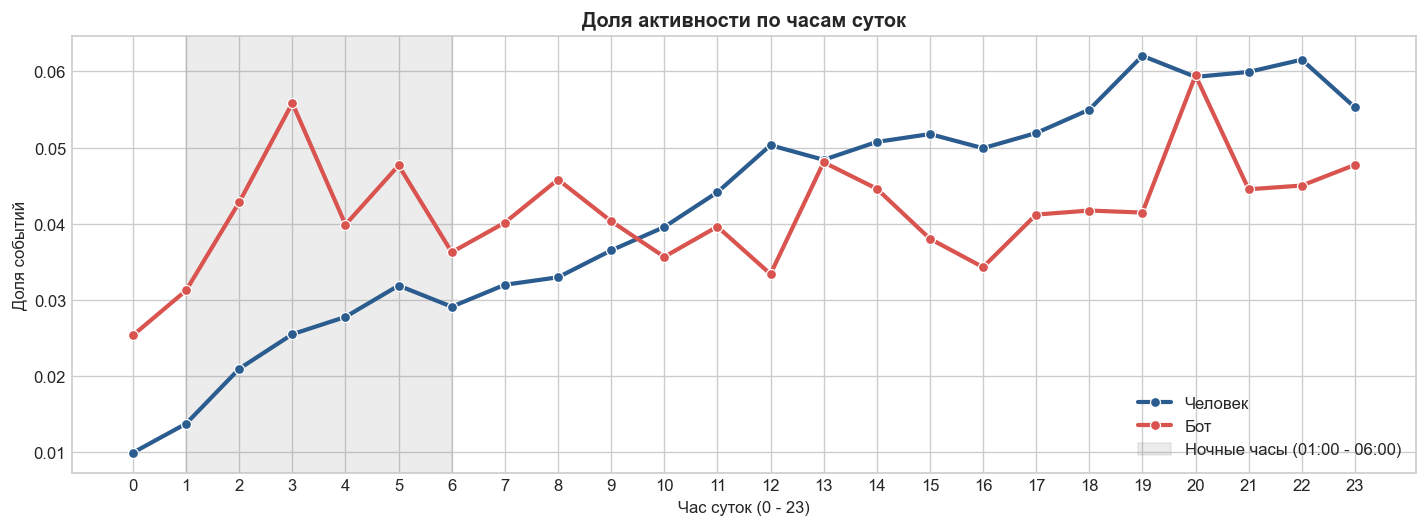

In [ ]:
ev_tr['hour'] = ev_tr.event_ts.dt.hour
hourly = ev_tr.groupby(['Class', 'hour']).size().reset_index(name='count')
hourly['ratio'] = hourly['count'] / hourly.groupby('Class')['count'].transform('sum')

plt.figure(figsize=(12, 4.5))
sns.lineplot(data=hourly, x='hour', y='ratio', hue='Class',hue_order=["Человек", "Бот"], marker='o', linewidth=2.5, palette=[COLOR_HUMAN, COLOR_BOT])
plt.axvspan(1, 6, color='gray', alpha=0.15, label='Ночные часы (01:00 - 06:00)')

plt.title("Доля активности по часам суток", fontsize=12, fontweight='bold')
plt.xlabel("Час суток (0 - 23)")
plt.ylabel("Доля событий")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

Бот также работает равномерно на всем промежутке времени, а у человека ночью активность снижается, поэтому признаки на основе ночного времени должны помочь

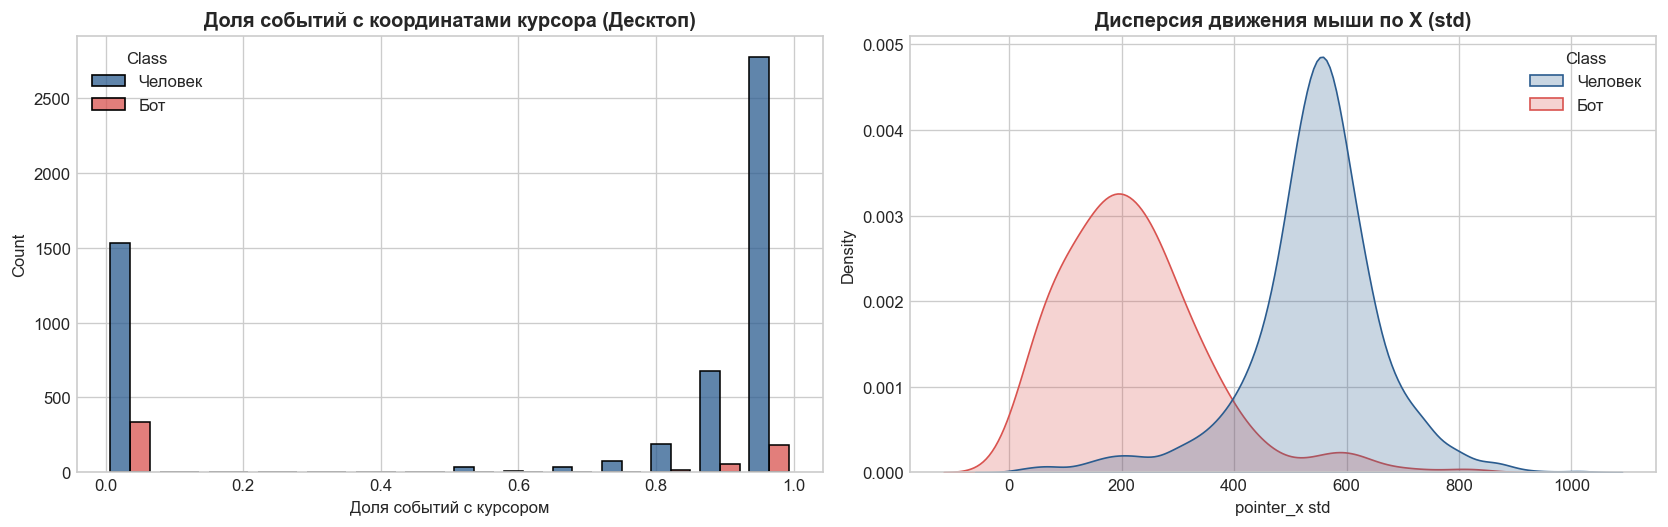

In [ ]:
desktop_ev = ev_tr[ev_tr.platform_clean.isin(['desktop', 'web'])].copy()

pointer_grp = desktop_ev.groupby(['cookie_id', 'Class']).agg(
    has_pointer=('pointer_x', lambda x: x.notna().mean()),
    x_std=('pointer_x', lambda x: x.std() if x.notna().sum() > 2 else 0)
).reset_index().fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(
    data=pointer_grp, 
    x='has_pointer', 
    hue='Class', 
    hue_order=["Человек", "Бот"],
    multiple='dodge', 
    shrink=0.8,
    palette=[COLOR_HUMAN, COLOR_BOT],
    ax=axes[0]
)
axes[0].set_title("Доля событий с координатами курсора (Десктоп)", fontweight='bold')
axes[0].set_xlabel("Доля событий с курсором")

sns.kdeplot(
    data=pointer_grp[pointer_grp.x_std > 0], 
    x='x_std', 
    hue='Class', 
    hue_order=["Человек", "Бот"],
    fill=True, 
    common_norm=False,
    palette=[COLOR_HUMAN, COLOR_BOT],
    ax=axes[1]
)
axes[1].set_title("Дисперсия движения мыши по X (std)", fontweight='bold')
axes[1].set_xlabel("pointer_x std")

plt.tight_layout()
plt.show()

Событий с курсором либо вообщще нет, либо присутствуют в полном объеме, но зато дисперсия ярка различаются между ботом и человеком, поэтому признак является важным если он есть

## Итог EDA

Датасет сильно несбалансированный, но при этом нет никаких пересечений, поэтому с дрифтом проблем нет. Валидация должна имитировать реальную природу данных.

Сам датасет содержит, как и пропуски, так и дубликаты. Дубликаты уберем, а пропуски имеют естественный характер, поэтому их заполнять не имеет смысла (либо заполнять None если реализация алгоритмов не имеют нативную подержку). Анализ также показал, что нужно производить Feature engineering, а точнее признаки на основе момент времени (давность кук, дельта времени между событиями и другие мат. операции, вложенность просмотра, разброс движения мыши и т.д.), общие характеристики, суточная активность, воронки, запросы и другие.

# Feature engineering

In [ ]:
import numpy as np
import pandas as pd
import os
import time

## Загрузка данных

In [ ]:
train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

def remove_duplicates(df, name):
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    after = len(df)
    print(f"{name}: удалено {before - after} дубликатов")
    return df

train = remove_duplicates(train, "train")
test = remove_duplicates(test, "test")
events = remove_duplicates(events, "events")

print(f"  train:  {train.shape}")
print(f"  test:   {test.shape}")
print(f"  events: {events.shape}")

train: удалено 0 дубликатов
test: удалено 0 дубликатов
events: удалено 4863 дубликатов
  train:  (11091, 5)
  test:   (4909, 4)
  events: (324042, 14)


## Фильтруем события в пределах окна

In [ ]:
def filter_window_events(events_df, meta_df):
    ev = events_df.merge(meta_df[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id', how='inner')
    ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)].copy()
    return ev.drop(columns=['window_start_ts', 'window_end_ts'])

ev_tr = filter_window_events(events, train)
ev_te = filter_window_events(events, test)

print(f"  Событий в окне Train: {len(ev_tr)}")
print(f"  Событий в окне Test:  {len(ev_te)}")

  Событий в окне Train: 195484
  Событий в окне Test:  88349


In [ ]:
# Список всех типов событий, для которых создаём счётчики и доли
ALL_EVENTS = [
    'item_view', 'search_results_view', 'photo_swipe',
    'contact_phone_show', 'contact_chat_open', 'contact_message_sent',
    'favorite_add', 'seller_page_view', 'login',
]

In [ ]:
def prepare_event_df(ev_df: pd.DataFrame) -> pd.DataFrame:
    """Обогащает DataFrame событий техническими, временными
    и поведенческими маркерами, нужными для последующей агрегации.
    """
    ev = ev_df.copy()

    # Нормализация строк платформы
    ev['platform_clean'] = ev['platform'].astype(str).str.lower()
    ua_str = ev['user_agent'].astype(str).str.lower()

    # Технические маркеры из User-Agent
    ev['is_crawler_lib'] = ua_str.str.contains(
        'scrapy|curl|requests|urllib|http-client|fetch|python', regex=True
    ).astype(int)
    ev['is_headless'] = ua_str.str.contains(
        'headlesschrome|phantomjs|selenium|playwright', regex=True
    ).astype(int)
    ev['is_avito_app'] = ua_str.str.contains(
        'okhttp|avito/', regex=True
    ).astype(int)

    # Маркеры платформы
    ev['is_desktop_plat'] = ev['platform_clean'].isin(['desktop', 'web']).astype(int)
    ev['is_mobile_plat'] = ev['platform_clean'].isin(['android', 'ios', 'iphone']).astype(int)
    
    # Сортировка и временные дельты между текущим и предыдущим событием того же cookie
    ev = ev.sort_values(['cookie_id', 'event_ts'], kind='mergesort')
    ev['dt'] = (
        ev.groupby('cookie_id', sort=False)['event_ts']
        .diff()
        .dt.total_seconds()
    )
    # Порядковый номер события внутри cookie
    ev['pos'] = ev.groupby('cookie_id', sort=False).cumcount()

    # Курсор
    ev['has_pointer'] = ev['pointer_x'].notna().astype(int)

    # Предыдущее событие
    ev['prev_event_name'] = (
        ev.groupby('cookie_id', sort=False)['event_name'].shift(1)
    )

    # Ночные часы
    ev['is_night'] = ev['event_ts'].dt.hour.isin([1, 2, 3, 4, 5]).astype(int)

    # One-hot по типам событий
    for e in ALL_EVENTS:
        ev[f'ev_{e}'] = (ev['event_name'] == e).astype(int)

    # Тип продавца
    ev['is_private_seller'] = (ev['seller_type'] == 'private').astype(int)
    ev['is_pro_seller'] = (ev['seller_type'] == 'pro').astype(int)

    # Биграммы переходов
    ev['trans_item_to_photo'] = (
        (ev['prev_event_name'] == 'item_view') &
        (ev['event_name'] == 'photo_swipe')
    ).astype(int)
    ev['trans_item_to_phone'] = (
        (ev['prev_event_name'] == 'item_view') &
        (ev['event_name'] == 'contact_phone_show')
    ).astype(int)
    ev['trans_item_to_item'] = (
        (ev['prev_event_name'] == 'item_view') &
        (ev['event_name'] == 'item_view')
    ).astype(int)
    ev['trans_search_to_search'] = (
        (ev['prev_event_name'] == 'search_results_view') &
        (ev['event_name'] == 'search_results_view')
    ).astype(int)
    ev['trans_photo_to_photo'] = (
        (ev['prev_event_name'] == 'photo_swipe') &
        (ev['event_name'] == 'photo_swipe')
    ).astype(int)

    # Доля событий после первого логина
    first_login = (
        ev[ev['event_name'] == 'login']
        .groupby('cookie_id')['pos']
        .min()
    )
    ev['after_login'] = (
        ev['pos'] > ev['cookie_id'].map(first_login)
    ).astype(float)

    # Максимальная длина серии одинаковых событий подряд
    ev['_chg'] = ev['event_name'].ne(
        ev.groupby('cookie_id', sort=False)['event_name'].shift()
    )
    ev['_run'] = ev.groupby('cookie_id', sort=False)['_chg'].cumsum()

    return ev

In [ ]:
def agg_base(ev: pd.DataFrame, g: pd.core.groupby.DataFrameGroupBy) -> pd.DataFrame:
    """Считает основные агрегаты по cookie_id:
    - число событий, длительность сессии, частоту;
    - статистики по dt (mean, std, median, квантили, доли быстрых/медленных);
    - ночную активность;
    - число уникальных часов активности.
    """
    f = pd.DataFrame(index=g.indices.keys())
    f.index.name = 'cookie_id'

    # Общие счётчики
    f['n_events'] = g.size()
    f['active_duration_sec'] = (
        (g['event_ts'].max() - g['event_ts'].min()).dt.total_seconds()
    )
    f['events_per_sec'] = f['n_events'] / (f['active_duration_sec'] + 1.0)

    # Статистики по dt
    f['dt_mean'] = g['dt'].mean()
    f['dt_std'] = g['dt'].std().fillna(0)
    f['dt_median'] = g['dt'].median()
    f['dt_min'] = g['dt'].min()
    f['dt_q25'] = g['dt'].quantile(0.25)
    f['dt_q75'] = g['dt'].quantile(0.75)
    f['dt_iqr'] = f['dt_q75'] - f['dt_q25']
    # Доля переходов быстрее 30 с
    f['dt_fast_ratio_30s'] = g['dt'].apply(lambda x: (x < 30.0).mean())
    # Доля переходов быстрее 1 с
    f['dt_fast_ratio_1s'] = g['dt'].apply(lambda x: (x < 1.0).mean())
    # Доля переходов быстрее 0.3 с
    f['dt_ultrafast_ratio_03s'] = g['dt'].apply(lambda x: (x < 0.3).mean())

    # Доля dt, попадающих точно в +-0.05 с от 1 с
    f['dt_int_bias_1s'] = g['dt'].apply(
        lambda x: (np.abs(x - 1.0) < 0.05).mean()
    )

    # Ночная активность
    f['night_events_cnt'] = g['is_night'].sum()
    f['night_events_ratio'] = f['night_events_cnt'] / f['n_events']
    f['active_hours_nunique'] = g['event_ts'].apply(lambda s: s.dt.hour.nunique())

    return f

In [ ]:
def agg_pointer_and_search(
    ev: pd.DataFrame,
    g: pd.core.groupby.DataFrameGroupBy,
    f: pd.DataFrame,
) -> pd.DataFrame:
    """Признаки указателя мыши (pointer) и глубины пагинации каталога."""

    # Курсор
    f['pointer_ratio'] = g['has_pointer'].mean()
    f['pointer_x_std'] = g['pointer_x'].std().fillna(0)
    f['pointer_y_std'] = g['pointer_y'].std().fillna(0)
    # Число уникальных пар (x, y)
    f['pointer_unique_pts'] = g.apply(
        lambda d: len(set(zip(d['pointer_x'].dropna(), d['pointer_y'].dropna())))
    )

    # Пагинация каталога
    f['search_page_max'] = g['search_page'].max().fillna(0)
    f['search_page_mean'] = g['search_page'].mean().fillna(0)
    f['search_page_std'] = g['search_page'].std().fillna(0)
    f['search_page_nunique'] = g['search_page'].nunique()
    f['is_deep_search_5'] = (f['search_page_max'] > 5).astype(int)
    f['is_deep_search_10'] = (f['search_page_max'] > 10).astype(int)
    f['is_deep_search_20'] = (f['search_page_max'] >= 20).astype(int)

    return f

In [ ]:
def agg_entities_and_ua(
    g: pd.core.groupby.DataFrameGroupBy,
    f: pd.DataFrame,
) -> pd.DataFrame:
    """Уникальные объявления, категории, локации, поисковые запросы,
    типы продавцов, характеристики User-Agent.
    """

    # Уникальные сущности
    f['item_nunique'] = g['item_id'].nunique()
    f['category_nunique'] = g['item_category'].nunique()
    f['location_nunique'] = g['item_location'].nunique()
    f['is_multi_location'] = (f['location_nunique'] > 5).astype(int)

    # Поисковые запросы
    f['query_nunique'] = g['search_query'].nunique()
    f['items_per_query'] = f['item_nunique'] / (f['query_nunique'] + 1.0)

    # Продавцы
    f['seller_private_cnt'] = g['is_private_seller'].sum()
    f['seller_pro_cnt'] = g['is_pro_seller'].sum()
    f['seller_private_ratio'] = f['seller_private_cnt'] / (f['item_nunique'] + 1e-5)
    f['seller_pro_ratio'] = f['seller_pro_cnt'] / (f['item_nunique'] + 1e-5)

    # User-Agent / платформа
    f['is_crawler_lib_max'] = g['is_crawler_lib'].max()
    f['is_headless_max'] = g['is_headless'].max()
    f['is_avito_app_max'] = g['is_avito_app'].max()
    f['is_desktop_max'] = g['is_desktop_plat'].max()
    # Десктоп без единого события с указателем
    f['desktop_no_pointer'] = (
        (f['is_desktop_max'] == 1) & (f['pointer_ratio'] == 0)
    ).astype(int)
    f['ua_nunique'] = g['user_agent'].nunique()

    return f

In [ ]:
def agg_event_counts_and_funnel(
    g: pd.core.groupby.DataFrameGroupBy,
    f: pd.DataFrame,
) -> pd.DataFrame:
    """Абсолютные счётчики и доли каждого типа событий.
    Счётчики биграмм переходов.
    """

    # Счётчики и доли
    for e in ALL_EVENTS:
        f[f'cnt_{e}'] = g[f'ev_{e}'].sum()
        f[f'ratio_{e}'] = f[f'cnt_{e}'] / f['n_events']

    # Воронка
    f['photo_to_item_ratio'] = f['cnt_photo_swipe'] / (f['cnt_item_view'] + 1.0)
    f['phone_to_item_ratio'] = f['cnt_contact_phone_show'] / (f['cnt_item_view'] + 1.0)
    f['chat_to_item_ratio'] = f['cnt_contact_chat_open'] / (f['cnt_item_view'] + 1.0)
    # Доля повторных просмотров одного и того же объявления
    f['item_repeat_ratio'] = 1.0 - (f['item_nunique'] / (f['cnt_item_view'] + 1e-5))
    f['total_contacts'] = (
        f['cnt_contact_phone_show'] +
        f['cnt_contact_chat_open'] +
        f['cnt_contact_message_sent']
    )
    f['total_contacts_ratio'] = f['total_contacts'] / f['n_events']

    # Биграммы
    f['trans_item_to_photo_cnt'] = g['trans_item_to_photo'].sum()
    f['trans_item_to_photo_ratio'] = (
        f['trans_item_to_photo_cnt'] / (f['cnt_item_view'] + 1.0)
    )
    f['trans_item_to_phone_cnt'] = g['trans_item_to_phone'].sum()
    f['trans_item_to_phone_ratio'] = (
        f['trans_item_to_phone_cnt'] / (f['cnt_item_view'] + 1.0)
    )
    f['trans_item_to_item_cnt'] = g['trans_item_to_item'].sum()
    f['trans_search_to_search_cnt'] = g['trans_search_to_search'].sum()
    f['trans_photo_to_photo_cnt'] = g['trans_photo_to_photo'].sum()

    return f

In [ ]:
def agg_catalog_traversal(
    ev: pd.DataFrame,
    g: pd.core.groupby.DataFrameGroupBy,
    f: pd.DataFrame,
) -> pd.DataFrame:
    """Признаки, специфичные для обхода каталога:
    - page_arith_run: максимальная длина серии страниц с шагом +1
    - items_per_search: сколько уникальных объявлений приходится
      на одно событие search_results_view;
    - item_pop_mean / item_pop_min: средняя и минимальная популярность
      просмотренных объявлений
    """

    # Арифметическая серия страниц
    search_df = (
        ev.dropna(subset=['search_page'])[['cookie_id', 'search_page']]
        .copy()
        .sort_values(['cookie_id', 'search_page'], kind='mergesort')
    )
    if len(search_df) > 0:
        # inc = True, если страница ровно на 1 больше предыдущей
        search_df['inc'] = (
            search_df.groupby('cookie_id', sort=False)['search_page']
            .diff()
            .eq(1)
        )
        # Разбиваем на runs подряд идущих True / False
        search_df['_chg'] = search_df['inc'].ne(
            search_df.groupby('cookie_id', sort=False)['inc'].shift()
        )
        search_df['_run'] = (
            search_df.groupby('cookie_id', sort=False)['_chg'].cumsum()
        )
        run_len = search_df.groupby(
            ['cookie_id', '_run', 'inc'], sort=False
        ).size()
        if True in run_len.index.get_level_values('inc'):
            f['page_arith_run'] = (
                run_len.xs(True, level='inc', drop_level=False)
                .groupby(level=0)
                .max()
            )
        else:
            f['page_arith_run'] = 0.0
    else:
        f['page_arith_run'] = 0.0
    f['page_arith_run'] = f['page_arith_run'].fillna(0.0)

    # Items per search
    f['items_per_search'] = f['item_nunique'] / (f['cnt_search_results_view'] + 1.0)
    
    # Популярность объявлений
    item_pop_df = ev.dropna(subset=['item_id']).copy()
    
    if len(item_pop_df) > 0:
        # Маппим каждому item_id число уникальных cookie, которые его смотрели
        local_pop = item_pop_df.groupby('item_id')['cookie_id'].nunique()
        item_pop_df['_pop'] = item_pop_df['item_id'].map(local_pop).fillna(0.0)
        pop_agg = item_pop_df.groupby('cookie_id', sort=False).agg(
            item_pop_mean=('_pop', 'mean'),
            item_pop_min=('_pop', 'min'),
        )
        f['item_pop_mean'] = np.log1p(pop_agg['item_pop_mean'].fillna(0.0))
        f['item_pop_min'] = np.log1p(pop_agg['item_pop_min'].fillna(0.0))
    else:
        f['item_pop_mean'] = 0.0
        f['item_pop_min'] = 0.0
    f['item_pop_mean'] = f['item_pop_mean'].fillna(0.0)
    f['item_pop_min'] = f['item_pop_min'].fillna(0.0)

    return f

In [ ]:
def agg_behaviour(
    ev: pd.DataFrame,
    g: pd.core.groupby.DataFrameGroupBy,
    f: pd.DataFrame,
) -> pd.DataFrame:
    """Дополнительные поведенческие метрики"""

    f['fav_per_search'] = f['cnt_favorite_add'] / (f['cnt_search_results_view'] + 1.0)
    f['contact_per_search'] = f['total_contacts'] / (f['cnt_search_results_view'] + 1.0)
    f['events_after_login_share'] = g['after_login'].mean().fillna(0.0)

    # Максимальная длина серии
    run_sizes = ev.groupby(['cookie_id', '_run'], sort=False).size()
    run_len_max_series = run_sizes.groupby('cookie_id', sort=False).max()
    f['run_len_max'] = run_len_max_series.reindex(f.index, fill_value=0.0)

    # Энтропия по долям типов событий
    # Собираем вектор долей; clip, чтобы log не ушёл в -inf
    shares = np.column_stack(
        [f[f'ratio_{e}'].fillna(0.0).values for e in ALL_EVENTS]
    )
    shares_clip = np.clip(shares, 1e-12, 1.0)
    f['event_entropy'] = -(shares_clip * np.log(shares_clip)).sum(axis=1)

    return f

In [ ]:
def agg_pagination(
    ev: pd.DataFrame,
    f: pd.DataFrame,
) -> pd.DataFrame:
    """Дополнительные признаки пагинации:
    - page_jump_mean — средний модуль скачка между страницами;
    - page_skip_share — доля скачков > 1 (пропуск страниц);
    - no_text_search — флаг полного отсутствия поисковых событий.
    """

    search_ev = ev.dropna(subset=['search_page'])

    if len(search_ev) > 0:
        page_jump = (
            search_ev
            .groupby('cookie_id', sort=False)['search_page']
            .diff()
            .abs()
        )
        f['page_jump_mean'] = page_jump.groupby(
            search_ev['cookie_id'], sort=False
        ).mean()
        f['page_skip_share'] = page_jump.gt(1).groupby(
            search_ev['cookie_id'], sort=False
        ).mean()
    else:
        f['page_jump_mean'] = 0.0
        f['page_skip_share'] = 0.0

    f['page_jump_mean'] = f['page_jump_mean'].fillna(0.0)
    f['page_skip_share'] = f['page_skip_share'].fillna(0.0)

    f['no_text_search'] = (f['cnt_search_results_view'] == 0).astype(int)

    return f

In [ ]:
def merge_meta(
    f: pd.DataFrame,
    meta_df: pd.DataFrame,
) -> pd.DataFrame:
    """Слияние агрегатов с метаданными cookie и добавление:
    - возраста cookie (часы, дни, log);
    - флагов свежей cookie и ночного создания;
    - кросс-признаков;
    - рангов внутри одного дня наблюдения.
    """

    res = meta_df[
        ['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']
    ].merge(f.reset_index(), on='cookie_id', how='left')

    # Возраст cookie
    res['cookie_age_hours'] = (
        (res['window_start_ts'] - res['cookie_created_at'])
        .dt.total_seconds() / 3600.0
    )
    res['cookie_age_days'] = res['cookie_age_hours'] / 24.0
    res['log_cookie_age_hours'] = np.log1p(np.maximum(0, res['cookie_age_hours']))
    res['is_fresh_cookie_24h'] = (res['cookie_age_hours'] < 24.0).astype(int)
    res['is_fresh_cookie_1h'] = (res['cookie_age_hours'] < 1.0).astype(int)

    # Час создания cookie
    res['created_hour'] = res['cookie_created_at'].dt.hour
    res['is_created_at_night'] = res['created_hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)
    res['is_created_cron_peak'] = res['created_hour'].isin([10, 15, 19, 21]).astype(int)

    #  Кросс-признаки
    res['item_uniq_x_new'] = (
        res['item_repeat_ratio'] *
        (res['cookie_age_days'] < 7.0).astype(float)
    ).fillna(0.0)

    # Много страниц и локаций, нет логина,
    # нормализованные на возраст cookie (насколько интенсивно обходились страницы)
    res['traverse_intensity'] = (
        (1.0 - (res['cnt_login'] > 0).astype(float))
        * np.log1p(res['search_page_max'])
        * np.log1p(res['location_nunique'])
        / (res['cookie_age_days'].clip(lower=0) + 1.0)
    ).fillna(0.0)

    # Логин × другие
    res['has_login'] = (res['cnt_login'] > 0).astype(int)
    res['login_x_locations'] = res['has_login'] * res['location_nunique']
    res['login_x_events'] = res['has_login'] * res['n_events']

    # Ранжирование внутри дня наблюдения
    # если сегодня все cookie просматривали < 5 страниц, а эта — 50,
    # ранг будет близок к 1.0.
    res['_day'] = res['window_start_ts'].dt.date

    peer_cols = [
        'n_events', 'location_nunique', 'item_nunique',
        'search_page_max', 'events_per_sec', 'dt_median',
    ]
    if 'item_pop_mean' in res.columns:
        peer_cols.append('item_pop_mean')

    for col in peer_cols:
        if col in res.columns:
            res[f'peer_{col}'] = res.groupby('_day')[col].rank(pct=True)

    res.drop(columns=['_day'], inplace=True)

    return res

In [ ]:
def extract_cookie_features(
    ev_df: pd.DataFrame,
    meta_df: pd.DataFrame,
    is_train: bool = True,
) -> pd.DataFrame:
    """Строит матрицу признаков по cookie_id."""

    ev = prepare_event_df(ev_df)
    g = ev.groupby('cookie_id', sort=False)
    f = agg_base(ev, g)
    f = agg_pointer_and_search(ev, g, f)
    f = agg_entities_and_ua(g, f)
    f = agg_event_counts_and_funnel(g, f)
    f = agg_catalog_traversal(ev, g, f)
    f = agg_behaviour(ev, g, f)
    f = agg_pagination(ev, f)
    res = merge_meta(f, meta_df)

    # Добавляем target (только для обучения) 
    if is_train and 'target' in meta_df.columns:
        res['target'] = meta_df['target'].values

    return res

In [ ]:
df_train_features = extract_cookie_features(ev_tr, train, is_train=True)
df_test_features = extract_cookie_features(ev_te, test, is_train=False)

print("\nРазмерности полученных матриц признаков:")
print(f"  df_train_features: {df_train_features.shape}")
print(f"  df_test_features:  {df_test_features.shape}")


Размерности полученных матриц признаков:
  df_train_features: (11091, 112)
  df_test_features:  (4909, 111)


Сохраняем

In [ ]:
os.makedirs('features', exist_ok=True)

# Сохраняем в Parquet и дублируем в CSV
df_train_features.to_parquet('features/train_features.parquet', index=False)
df_test_features.to_parquet('features/test_features.parquet', index=False)

df_train_features.to_csv('features/train_features.csv', index=False)
df_test_features.to_csv('features/test_features.csv', index=False)

В итоге получили около 100 новых признаков, которые в дальнейшем пойдут на обучение, при этом пропуски не обрабатывались потому что все зависит от выбраного алгоритма

## 1. Импорты, настройки и загрузка данных

In [ ]:
import json
import warnings
import time
import pickle
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import optuna
from optuna.samplers import TPESampler

from metric import precision_at_recall

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT         = Path(".")
FEATURES_DIR = ROOT / "features"
RESULTS_DIR  = ROOT / "results"
PROCESSED_DIR = ROOT / "processed"
RESULTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

TARGET       = "target"
RANDOM_STATE = 42
GAP_DAYS     = 0
MIN_TRAIN_DAYS = 9


# Загрузка данных 
if (FEATURES_DIR / "train_features.parquet").exists():
    print("Загрузка из features/train_features.parquet ...")
    train_fe = pd.read_parquet(FEATURES_DIR / "train_features.parquet")
    test_fe  = pd.read_parquet(FEATURES_DIR / "test_features.parquet")
else:
    print("Загрузка из features/train_features.csv ...")
    train_fe = pd.read_csv(FEATURES_DIR / "train_features.csv")
    test_fe  = pd.read_csv(FEATURES_DIR / "test_features.csv")

# Приведение даты
train_fe["window_start_ts"] = pd.to_datetime(train_fe["window_start_ts"])
if "window_start_ts" in test_fe.columns:
    test_fe["window_start_ts"] = pd.to_datetime(test_fe["window_start_ts"])

# Служебные колонки, которые нельзя подавать модели
META_COLS = {"cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts", TARGET}
feature_columns = [c for c in train_fe.columns if c not in META_COLS]
cat_features    = [c for c in feature_columns if train_fe[c].dtype == "object"]
num_features    = [c for c in feature_columns if c not in cat_features]

print(f"train_fe : {train_fe.shape}")
print(f"test_fe  : {test_fe.shape}")
print(f"features : {len(feature_columns)}  (cat={len(cat_features)}, num={len(num_features)})")
print(f"target rate: {train_fe[TARGET].mean():.4f}")

Загрузка из features/train_features.parquet ...
train_fe : (11091, 112)
test_fe  : (4909, 111)
features : 107  (cat=0, num=107)
target rate: 0.0811


## 2. Временная кросс-валидация

В этом блоке строится схема валидации. Разбиение идёт по дням: модель обучается на прошлых днях после этого проверяется на одном следующем дне.


In [ ]:
def make_expanding_daily_folds(df, date_col="window_start_ts",
                               gap_days=GAP_DAYS, min_train_days=MIN_TRAIN_DAYS):
    dates = np.array(sorted(df[date_col].dt.normalize().unique()))
    folds = []
    for vp in range(min_train_days + gap_days, len(dates)):
        tr_dates = dates[:vp - gap_days] if gap_days > 0 else dates[:vp]
        va_dates = [dates[vp]]
        if len(tr_dates) < min_train_days:
            continue
        tr = df.index[df[date_col].dt.normalize().isin(tr_dates)].to_numpy()
        va = df.index[df[date_col].dt.normalize().isin(va_dates)].to_numpy()
        if len(tr) and len(va):
            folds.append((tr, va))
    return folds


folds = make_expanding_daily_folds(train_fe)
print(f"\nFolds: {len(folds)}")
for i, (tr, va) in enumerate(folds, 1):
    d_tr_min = train_fe.loc[tr, "window_start_ts"].min().date()
    d_tr_max = train_fe.loc[tr, "window_start_ts"].max().date()
    d_va     = train_fe.loc[va, "window_start_ts"].iloc[0].date()
    print(f"  {i}: train {d_tr_min}..{d_tr_max} ({len(tr)}) | valid {d_va} ({len(va)})")


Folds: 5
  1: train 2026-04-06..2026-04-14 (7599) | valid 2026-04-15 (801)
  2: train 2026-04-06..2026-04-15 (8400) | valid 2026-04-16 (740)
  3: train 2026-04-06..2026-04-16 (9140) | valid 2026-04-17 (713)
  4: train 2026-04-06..2026-04-17 (9853) | valid 2026-04-18 (606)
  5: train 2026-04-06..2026-04-18 (10459) | valid 2026-04-19 (632)


## 3. Метрика и веса объектов

Функция `make_sample_weights` задаёт веса так, чтобы каждый день вносил одинаковый вклад в обучение. Для этого каждому объекту даётся вес, обратный числу куки в его дне, а потом веса нормализуются к среднему значению 1.

In [ ]:
def make_sample_weights(df, date_col="window_start_ts"):
    """Равный вклад каждого дня в лосс."""
    sizes = df.groupby(date_col)["cookie_id"].transform("size").astype(float)
    w = (1.0 / sizes).values
    return w / w.mean()

## 4. Препроцессинг для линейных моделей

В этом блоке строится preprocessing для линейных моделей. Для деревьев отдельная обработка не нужна, потому что они умеют работать с пропусками и категориями более естественно.

Для числовых признаков используется заполнение пропусков медианой и масштабирование через `StandardScaler`. Это нужно, чтобы линейная модель корректно работала с признаками разных масштабов.

Для категориальных признаков пропуски заменяются на `"NA"`, а затем применяется One-Hot Encoding. Такой способ безопасен, прост и хорошо подходит при небольшой кардинальности категорий.



In [ ]:
def build_linear_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="NA")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ])

## 5. Набор моделей для сравнения

В этом блоке задаётся список моделей, которые будут сравниваться на одинаковой кросс-валидации.

Параметры выбраны без сильного тюнинга. На этом этапе задача в том, чтобы честно сравнить модели в одинаковых условиях и выбрать лучший базовый вариант.

In [ ]:
# Параметры моделей
MODELS = {
    "LogReg": ("logreg", dict(
        solver="lbfgs", max_iter=2000,
        class_weight="balanced", random_state=RANDOM_STATE,
    )),
    "LightGBM": ("lightgbm", dict(
        objective="binary", metric="average_precision",
        n_estimators=1000, verbose=-1,
    )),
    "XGBoost": ("xgboost", dict(
        objective="binary:logistic", eval_metric="aucpr",
        n_estimators=1000, tree_method="hist",
        early_stopping_rounds=50, verbosity=0,
    )),
    "CatBoost": ("catboost", dict(
        loss_function="Logloss", eval_metric="PRAUC",
        iterations=1000, verbose=0,
        allow_writing_files=False,
    )),
}

## 6. Единый CV runner

Это основной блок, который отвечает за запуск моделей на одинаковых фолдах.

Сначала задаются вспомогательные функции. `_get_features` собирает список признаков и делит их на категориальные и числовые. `_lgbm_data` подготавливает данные для LightGBM, переводя категориальные признаки в тип `category`.

Функция `run_cv` проходит по всем фолдам. На каждом фолде она:
- выделяет train и validation
- выбирает нужные признаки
- считает sample weights
- обучает модель нужного типа
- получает предсказания на train и valid
- считает метрику на train и valid
- сохраняет OOF-предсказания и время обучения


In [ ]:
_SKIP_COLS = META_COLS

def _get_features(tr, va, drop=()):
    drop = set(drop)
    feats = [c for c in tr.columns if c not in _SKIP_COLS and c not in drop and c in va.columns]
    cats  = [c for c in feats if tr[c].dtype == "object"]
    nums  = [c for c in feats if c not in cats]
    return feats, cats, nums


def _lgbm_data(tr, va, feats, cats):
    tr_l, va_l = tr[feats].copy(), va[feats].copy()
    for c in cats:
        tr_l[c] = tr_l[c].astype("category")
        va_l[c] = va_l[c].astype("category")
    return tr_l, va_l


def run_cv(model_type, params, train_fe, folds, drop_features=None):
    oof          = np.full(len(train_fe), np.nan)
    fold_scores  = []
    train_scores = []
    fit_times    = []

    _ES_KEYS = {"early_stopping_rounds", "use_best_model"}

    for fold_num, (tr_idx, va_idx) in enumerate(folds, 1):
        tr = train_fe.iloc[tr_idx].reset_index(drop=True)
        va = train_fe.iloc[va_idx].reset_index(drop=True)
        feats, cats, nums = _get_features(tr, va, drop=drop_features or [])
        w = make_sample_weights(tr)

        t0 = time.time()

        if model_type == "catboost":
            p = {k: v for k, v in params.items() if k not in _ES_KEYS}
            model = CatBoostClassifier(**p, random_seed=RANDOM_STATE)
            model.fit(
                Pool(tr[feats], tr[TARGET], cat_features=cats, weight=w),
                eval_set=Pool(va[feats], va[TARGET], cat_features=cats),
                use_best_model=True, early_stopping_rounds=100,
            )
            pred_tr = model.predict_proba(Pool(tr[feats], cat_features=cats))[:, 1]
            pred_va = model.predict_proba(Pool(va[feats], cat_features=cats))[:, 1]

        elif model_type == "lightgbm":
            tr_l, va_l = _lgbm_data(tr, va, feats, cats)
            model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
            model.fit(tr_l, tr[TARGET], sample_weight=w,
                      eval_set=[(va_l, va[TARGET])], categorical_feature=cats,
                      callbacks=[lgb.early_stopping(150, verbose=False)])
            pred_tr = model.predict_proba(tr_l)[:, 1]
            pred_va = model.predict_proba(va_l)[:, 1]

        elif model_type == "xgboost":
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            if cats:
                ohe.fit(tr[cats].astype(str))
                tr_X = np.hstack([tr[nums].fillna(0).values, ohe.transform(tr[cats].astype(str))])
                va_X = np.hstack([va[nums].fillna(0).values, ohe.transform(va[cats].astype(str))])
            else:
                tr_X = tr[nums].fillna(0).values
                va_X = va[nums].fillna(0).values
            p = {k: v for k, v in params.items() if k != "enable_categorical"}
            model = xgb.XGBClassifier(**p, random_state=RANDOM_STATE)
            model.fit(tr_X, tr[TARGET], sample_weight=w,
                      eval_set=[(va_X, va[TARGET])], verbose=False)
            pred_tr = model.predict_proba(tr_X)[:, 1]
            pred_va = model.predict_proba(va_X)[:, 1]

        elif model_type == "logreg":
            model = Pipeline([
                ("prep", build_linear_preprocessor(nums, cats)),
                ("clf",  LogisticRegression(**params)),
            ])
            model.fit(tr[feats], tr[TARGET], clf__sample_weight=w)
            pred_tr = model.predict_proba(tr[feats])[:, 1]
            pred_va = model.predict_proba(va[feats])[:, 1]

        else:
            raise ValueError(model_type)

        fit_times.append(time.time() - t0)
        tr_m = float(precision_at_recall(tr[TARGET].values, pred_tr))
        va_m = float(precision_at_recall(va[TARGET].values, pred_va))
        oof[va_idx] = pred_va
        fold_scores.append(va_m)
        train_scores.append(tr_m)
        print(f"  Fold {fold_num}: train={tr_m:.5f}  valid={va_m:.5f}  "
              f"gap={tr_m-va_m:+.5f}  fit={fit_times[-1]:.1f}s")

    return oof, fold_scores, train_scores, fit_times

## 7. Сравнение базовых моделей

В этом блоке по очереди запускаются все модели из словаря `MODELS`.

In [ ]:
results        = {}
oof_predictions = {}
# Прогоняем каждую модель и сохраняем результаты
for name, (mtype, params) in MODELS.items():
    print(f"\n{name}\n")
    oof, scores, tr_scores, times = run_cv(mtype, params, train_fe, folds)
    gaps = np.array(tr_scores) - np.array(scores)
    results[name] = dict(
        mean_ap=np.mean(scores), std_ap=np.std(scores),
        min_ap=np.min(scores),   max_ap=np.max(scores),
        mean_gap=gaps.mean(),    mean_fit_s=np.mean(times),
    )
    oof_predictions[name] = oof

comparison_df = (
    pd.DataFrame(results).T
    .sort_values("mean_ap", ascending=False)
    .round(5)
)
display(comparison_df)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv")


LogReg

  Fold 1: train=0.66154  valid=0.79661  gap=-0.13507  fit=0.2s
  Fold 2: train=0.71257  valid=0.60870  gap=+0.10388  fit=0.2s
  Fold 3: train=0.72245  valid=0.68116  gap=+0.04130  fit=0.2s
  Fold 4: train=0.71033  valid=0.51389  gap=+0.19644  fit=0.3s
  Fold 5: train=0.69686  valid=0.72093  gap=-0.02407  fit=0.3s

LightGBM

  Fold 1: train=1.00000  valid=0.90909  gap=+0.09091  fit=0.6s
  Fold 2: train=1.00000  valid=0.79630  gap=+0.20370  fit=0.7s
  Fold 3: train=1.00000  valid=0.85455  gap=+0.14545  fit=2.5s
  Fold 4: train=1.00000  valid=0.74510  gap=+0.25490  fit=0.9s
  Fold 5: train=1.00000  valid=0.91176  gap=+0.08824  fit=0.8s

XGBoost

  Fold 1: train=1.00000  valid=0.90196  gap=+0.09804  fit=0.4s
  Fold 2: train=0.99374  valid=0.71186  gap=+0.28187  fit=0.3s
  Fold 3: train=0.98855  valid=0.74603  gap=+0.24252  fit=0.3s
  Fold 4: train=1.00000  valid=0.82609  gap=+0.17391  fit=1.0s
  Fold 5: train=1.00000  valid=0.89189  gap=+0.10811  fit=0.8s

CatBoost

  Fold 1: trai

,mean_ap,std_ap,min_ap,max_ap,mean_gap,mean_fit_s
LightGBM,0.84336,0.06480,0.74510,0.91176,0.15664,1.08689
CatBoost,0.83236,0.06290,0.76000,0.92727,0.15914,4.76802
XGBoost,0.81557,0.07614,0.71186,0.90196,0.18089,0.56157
LogReg,0.66426,0.09666,0.51389,0.79661,0.03650,0.24562


Заметим, что есть явное переобучение на данных при использовании деревьев. При попытках решения пробовался и исходный датасет и там тоже было переобучение, поэтому можно сказать, что оно связано с малым количеством данных и на данном этапе это можно победить сильной регуляризацией. Я тестировал этот вариант, но модель приходится сильно "душить" и не дает прироста именно в валидирующей метрике. Выбор пал на LGBM, т.к. он быстрее и показал лучшие результаты.

## 8. Permutation importance по фолдам

В этом блоке считается важность признаков через permutation importance на модели LightGBM.

Идея метода: сначала измеряется качество модели на validation, затем значения одного признака перемешиваются, и качество считается заново. Если после перемешивания качество падает, значит признак полезен.

Функция `permutation_importance_manual` делает это для одного validation-набора. Для каждого признака проводится несколько повторов перемешивания, чтобы оценка была стабильнее.

Функция `collect_fold_importances` повторяет этот расчёт на каждом фолде, а затем объединяет результаты. 

In [ ]:
def permutation_importance_manual(model, X_val, y_val, cats, n_repeats=5, seed=42):
    def _score(X):
        Xc = X.copy()
        for c in cats:
            if c in Xc.columns:
                Xc[c] = Xc[c].astype("category")
        return precision_at_recall(y_val, model.predict_proba(Xc)[:, 1])

    # Baseline: метрика на исходных (неиспорченных) данных
    baseline = _score(X_val)
    means, stds = [], []

    for col in X_val.columns:
        drops = []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            # Перемешиваем значения признака случайно
            Xp[col] = Xp[col].sample(frac=1, random_state=seed).values
            drops.append(baseline - _score(Xp))
        means.append(np.mean(drops))
        stds.append(np.std(drops))

    return np.array(means), np.array(stds), baseline


def collect_fold_importances(params, train_fe, folds, n_repeats=5):
    """
    Считает permutation importance по всем фолдам и агрегирует результаты.
    """
    all_imps = []

    for fold_num, (tr_idx, va_idx) in enumerate(folds, 1):
        tr = train_fe.iloc[tr_idx].reset_index(drop=True)
        va = train_fe.iloc[va_idx].reset_index(drop=True)
        feats, cats, _ = _get_features(tr, va)
        tr_l, va_l = _lgbm_data(tr, va, feats, cats)
        w = make_sample_weights(tr)
        
        # Обучаем LightGBM на текущем фолде
        model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
        model.fit(tr_l, tr[TARGET], 
                  sample_weight=w,
                  eval_set=[(va_l, va[TARGET])], 
                  categorical_feature=cats,
                  callbacks=[lgb.early_stopping(100, verbose=False),
                              lgb.log_evaluation(-1)])
        
        # Считаем permutation importance на валидационной части фолда
        imp_mean, imp_std, baseline = permutation_importance_manual(
            model, va_l, va[TARGET].values, cats,
            n_repeats=n_repeats, seed=RANDOM_STATE,
        )
        
        # Самый важный признак в этом фолде
        top = feats[int(imp_mean.argmax())]
        print(f"  Fold {fold_num}: baseline={baseline:.5f} | top={top} ({imp_mean.max():.5f})")

        all_imps.append(pd.DataFrame({
            "feature":          feats,
            f"mean_{fold_num}": imp_mean,
            f"std_{fold_num}":  imp_std,
        }))

    # Объединяем все фолды в одну таблицу по колонке feature
    imp_df = all_imps[0][["feature"]].copy()
    for d in all_imps:
        imp_df = imp_df.merge(d, on="feature", how="left")

    # Находим колонки с результатами по фолдам
    mean_cols = [c for c in imp_df.columns if c.startswith("mean_")]
    std_cols  = [c for c in imp_df.columns if c.startswith("std_")]

    imp_df[mean_cols + std_cols] = imp_df[mean_cols + std_cols].fillna(0)
    
    # Среднее падение AP по всем фолдам — основная метрика важности
    imp_df["gain_mean"]        = imp_df[mean_cols].mean(axis=1)
    
    # Разброс важности между фолдами:
    imp_df["gain_std"]         = imp_df[mean_cols].std(axis=1)
    
    # Среднее внутрифолдовое std:
    imp_df["repeat_std_mean"]  = imp_df[std_cols].mean(axis=1)
    
    imp_df["n_folds_positive"] = (imp_df[mean_cols] > 0).sum(axis=1)
    imp_df["n_folds_negative"] = (imp_df[mean_cols] < 0).sum(axis=1)

    # Доля важности признака от суммы всех положительных важностей
    pos_total = imp_df["gain_mean"].clip(lower=0).sum()
    imp_df["gain_pct"] = imp_df["gain_mean"].clip(lower=0) / max(pos_total, 1e-12) * 100

    return (imp_df.sort_values("gain_mean", ascending=False)
                  .reset_index(drop=True)
                  .assign(rank=lambda d: range(1, len(d) + 1)))


print("Collecting permutation importances")
imp_df = collect_fold_importances(MODELS["LightGBM"][1], train_fe, folds, n_repeats=20)
print(f"\nFeatures: {len(imp_df)} | "
      f"positive-all-folds={( imp_df['n_folds_positive']==len(folds)).sum()} | "
      f"negative-3+={(imp_df['n_folds_negative']>=3).sum()}")
imp_df.to_csv(RESULTS_DIR / "feature_importance_permutation.csv", index=False)

  Fold 1: baseline=0.90909 | top=item_pop_mean (0.33409)
  Fold 2: baseline=0.79630 | top=pointer_x_std (0.44336)
  Fold 3: baseline=0.75000 | top=pointer_unique_pts (0.44811)
  Fold 4: baseline=0.74510 | top=pointer_x_std (0.44182)
  Fold 5: baseline=0.91176 | top=pointer_x_std (0.65973)

Features: 107 | positive-all-folds=6 | negative-3+=8


## 9. Визуализация важности признаков

В этом блоке строится график по результатам permutation importance.

Функция `plot_importances` показывает:
- top-N самых важных признаков
- накопленную важность
- стабильность признаков по фолдам

На первом графике признаки дополнительно раскрашиваются по стабильности: видно, какие из них полезны почти всегда, а какие ведут себя нестабильно.

Также внизу печатается короткая сводка: сколько признаков покрывают 80%, 90%, 95% и 99% общей важности, сколько признаков полезны на всех фолдах и сколько выглядят как кандидаты на удаление.

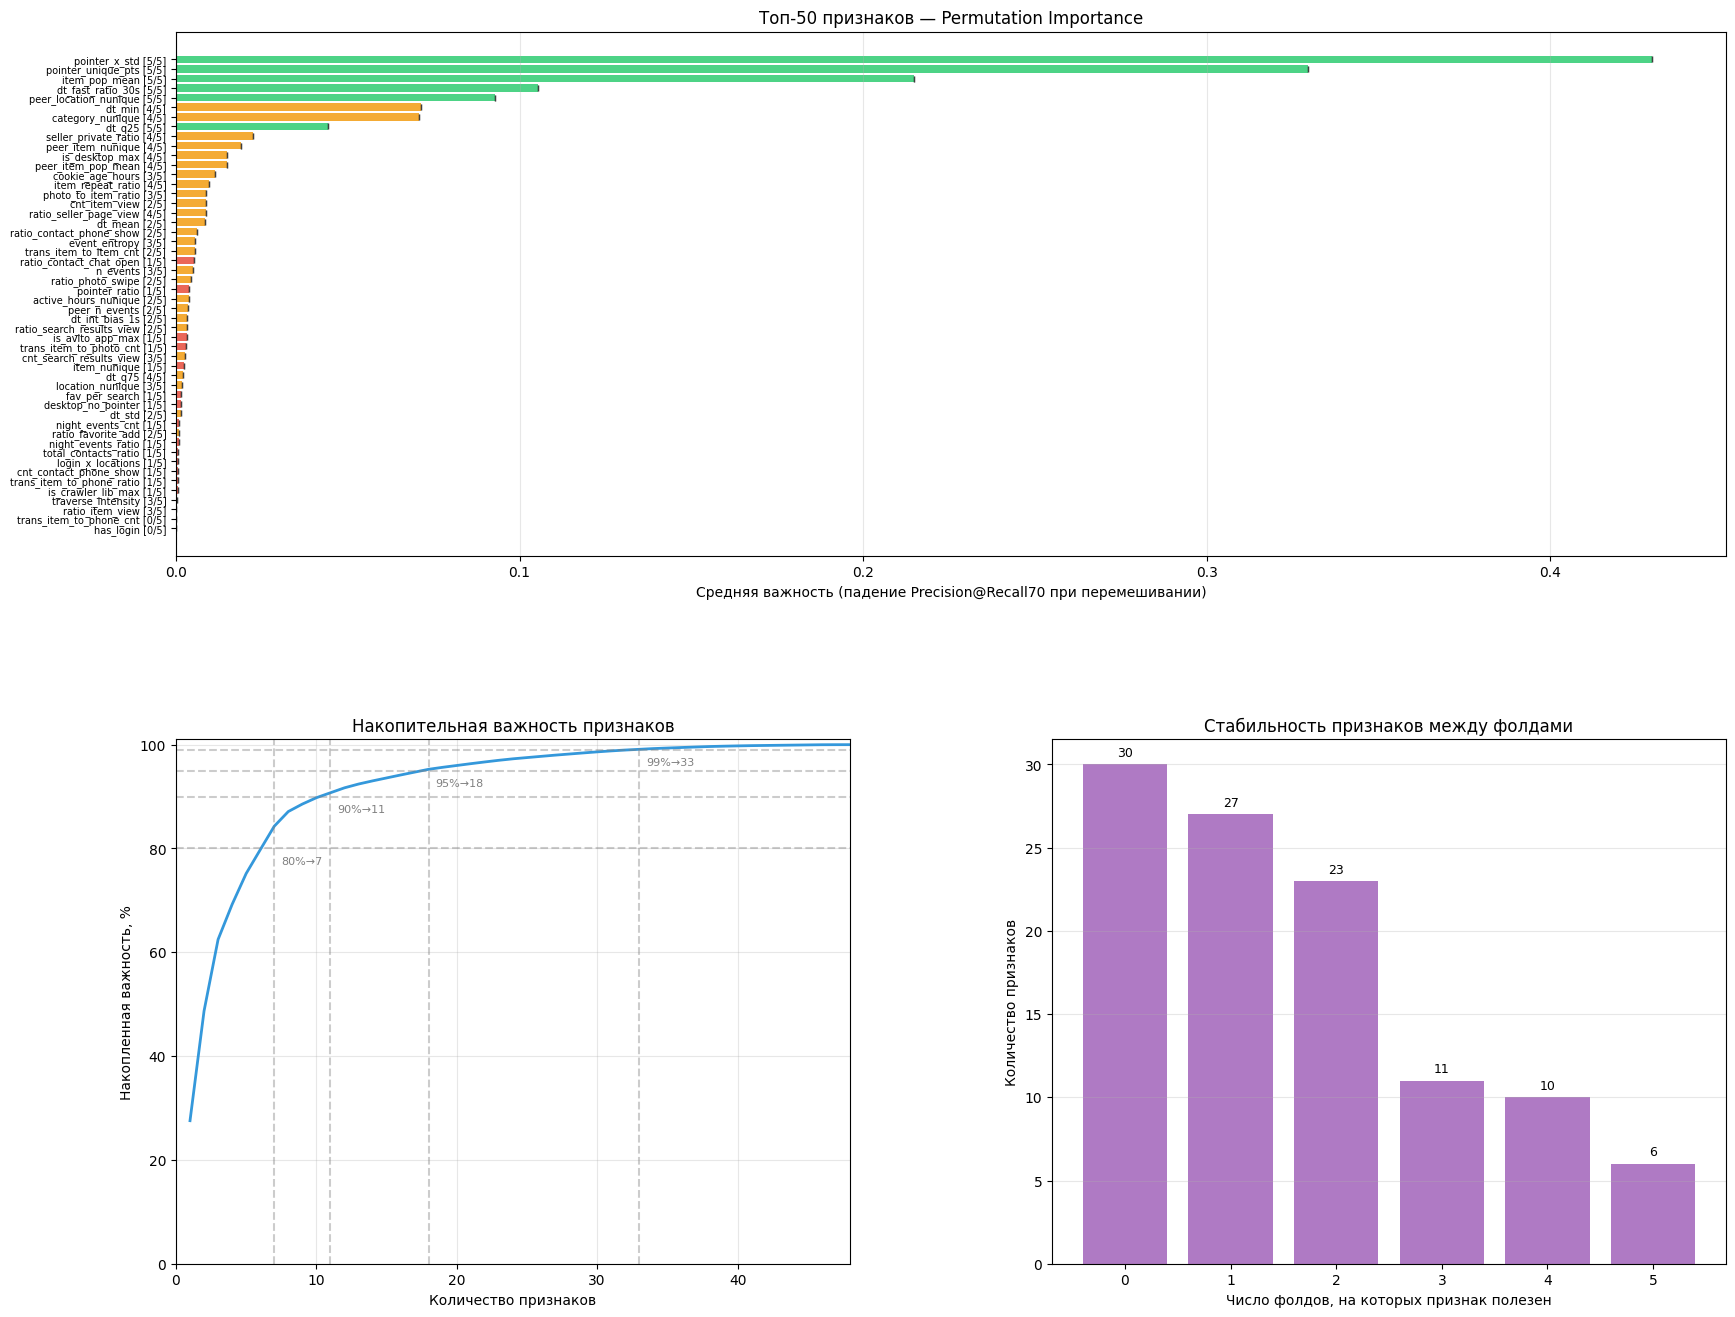


Сводка по PERMUTATION IMPORTANCE
  80% - top 7 features
  90% - top 11 features
  95% - top 18 features
  99% - top 33 features


In [ ]:
def plot_importances(imp_df, folds, top_n=50):
    n_folds = len(folds)
    fig = plt.figure(figsize=(20, 16))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # top-N признаков
    ax1  = fig.add_subplot(gs[0, :])
    top  = imp_df.head(top_n)
    colors = [
        "#2ecc71" if r["n_folds_positive"] == n_folds
        else "#f39c12" if r["n_folds_positive"] >= n_folds // 2
        else "#e74c3c"
        for _, r in top.iterrows()
    ]
    ax1.barh(range(top_n-1, -1, -1), top["gain_mean"].values, color=colors, alpha=0.85)
    ax1.errorbar(top["gain_mean"].values, range(top_n-1, -1, -1),
                 xerr=top["repeat_std_mean"].values,
                 fmt="none", color="black", alpha=0.5, capsize=2, linewidth=0.8)
    ax1.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax1.set_yticks(range(top_n-1, -1, -1))
    ax1.set_yticklabels(
        [f"{r['feature']} [{int(r['n_folds_positive'])}/{n_folds}]" for _, r in top.iterrows()],
        fontsize=7)
    ax1.set_xlabel("Средняя важность (падение Precision@Recall70 при перемешивании)")
    ax1.set_title(f"Топ-{top_n} признаков — Permutation Importance")
    ax1.grid(alpha=0.3, axis="x")

    # Накопительная сумма по средней важности
    ax2    = fig.add_subplot(gs[1, 0])
    pos_df = imp_df[imp_df["gain_mean"] > 0]
    cumsum = pos_df["gain_pct"].cumsum().values
    ax2.plot(range(1, len(cumsum)+1), cumsum, color="#3498db", linewidth=2)
    for thr in [80, 90, 95, 99]:
        if cumsum[-1] >= thr:
            n = int(np.searchsorted(cumsum, thr)) + 1
            ax2.axhline(thr, color="gray", linestyle="--", alpha=0.4)
            ax2.axvline(n,   color="gray", linestyle="--", alpha=0.4)
            ax2.text(n+.5, thr-3, f"{thr}%→{n}", fontsize=8, color="gray")
    ax2.set(xlabel="Количество признаков", ylabel="Накопленная важность, %",
            title="Накопительная важность признаков",
            xlim=(0, min(200, len(cumsum))), ylim=(0, 101))
    ax2.grid(alpha=0.3)

    # Количество стабильных на фолдах
    ax3 = fig.add_subplot(gs[1, 1])
    vc  = imp_df["n_folds_positive"].value_counts().sort_index()
    bars = ax3.bar(vc.index, vc.values, color="#9b59b6", alpha=0.8)
    for b, v in zip(bars, vc.values):
        ax3.text(b.get_x()+b.get_width()/2, b.get_height()+.3, str(v),
                 ha="center", va="bottom", fontsize=9)
    ax3.set(xlabel="Число фолдов, на которых признак полезен",
            ylabel="Количество признаков",
            title="Стабильность признаков между фолдами",
            xticks=range(n_folds+1))
    ax3.grid(alpha=0.3, axis="y")

    plt.savefig(RESULTS_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


    print("\nСводка по PERMUTATION IMPORTANCE")
    for thr in [80, 90, 95, 99]:
        if len(cumsum) and cumsum[-1] >= thr:
            print(f"  {thr}% - top {int(np.searchsorted(cumsum,thr))+1} features")

plot_importances(imp_df, folds, top_n=50)

## Итоги по графику permutation importance

**Топ признаков и их характер**

В самом верху рейтинга находятся признаки, описывающие физическую динамику курсора (указателя) и тайминги действий


**Стабильность признаков**

Тут можно увидеть что самые важные признаки были полезны на всех фолдах, а менее важные не всегда, что говорит о надежности признака при разных данных

**Накопленная важность**

График cumulative importance показывает очень концентрированное распределение:
- 80% важности дают всего **7 признаков**
- 90% важности — **11 признаков**
- 95% важности — **18 признаков**
- 99% важности — **33 признака**

Это значит, что большая часть сигнала сосредоточена в очень небольшом ядре фичей, а остальные признаки в основном дублируют информацию или добавляют шум.

**Стабильность по фолдам**

Правый график показывает, что из всех признаков:
- **30** вообще не дают положительного вклада ни на одном фолде — их можно смело удалять
- **27** полезны только на 1 фолде — скорее всего случайные всплески из за структуры фолда.
- только **6** признака полезны на всех 5 фолдах — это самое надёжные признаки
- ещё **10** полезны на 5 фолдах — тоже стабильные

## 10. Отбор признаков и сравнение подмножеств

После расчёта важности в этом блоке формируются разные наборы признаков и сравниваются между собой.

Функция `select_features` умеет выбирать признаки несколькими способами:
- по накопленной важности, например до 90% или 95%
- по top-N
- по числу фолдов, где признак был полезен
- все признаки с положительной важностью

В конце выбирается лучшее подмножество признаков, которое пойдёт дальше в HPO и финальное обучение.

In [ ]:
def select_features(imp_df, strategy="gain_pct", threshold=95):
    """Выбор стратегии отбора фич"""
    neg = set(imp_df[imp_df["gain_mean"] < 0]["feature"])
    pos = imp_df[imp_df["gain_mean"] > 0]

    if strategy == "gain_pct":
        n = int(np.searchsorted(pos["gain_pct"].cumsum().values, threshold)) + 1
        sel = pos.head(n)["feature"].tolist()
    elif strategy == "top_n":
        sel = pos.head(threshold)["feature"].tolist()
    elif strategy == "min_folds":
        sel = imp_df[(imp_df["n_folds_positive"] >= threshold) &
                     (imp_df["gain_mean"] > 0)]["feature"].tolist()
    elif strategy == "nonzero":
        sel = pos["feature"].tolist()
    else:
        raise ValueError(strategy)

    print(f"  {strategy}={threshold}: {len(sel)} features  ({len(neg)} negative dropped)")
    return sel


n_folds = len(folds)
subsets = {
    "all_features":     [c for c in train_fe.columns if c not in _SKIP_COLS],
    "gain_pct_95":      select_features(imp_df, "gain_pct", 95),
    "gain_pct_90":      select_features(imp_df, "gain_pct", 90),
    "top100":           select_features(imp_df, "top_n", 100),
    "stable_all_folds": select_features(imp_df, "min_folds", n_folds),
    "nonzero":          select_features(imp_df, "nonzero"),
}


def compare_subsets(subsets, params, train_fe, folds):
    """Сравнение разных множеств признаков"""
    print("\nСводка")
    results = {}

    for name, features in subsets.items():
        fold_scores = []
        for fold_num, (tr_idx, va_idx) in enumerate(folds, 1):
            tr = train_fe.iloc[tr_idx].reset_index(drop=True)
            va = train_fe.iloc[va_idx].reset_index(drop=True)
            
            use = [c for c in features if c in tr.columns and c in va.columns]
            cats = [c for c in use if tr[c].dtype == "object"]
            
            tr_l, va_l = _lgbm_data(tr, va, use, cats)
            w = make_sample_weights(tr)
            
            model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
            model.fit(tr_l, tr[TARGET], sample_weight=w,
                      eval_set=[(va_l, va[TARGET])], categorical_feature=cats,
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                  lgb.log_evaluation(-1)])
            preds_va = model.predict_proba(va_l)[:, 1]
            fold_scores.append(precision_at_recall(va[TARGET].values, preds_va))

        m, s = float(np.mean(fold_scores)), float(np.std(fold_scores))
        results[name] = {"mean": m, "std": s, "folds": fold_scores}
        print(f"  {name:22s}: {m:.5f} ± {s:.5f}  "
              f"[{' | '.join(f'{x:.4f}' for x in fold_scores)}]  n={len(features)}")
    return results


subset_results = compare_subsets(subsets, MODELS["LightGBM"][1], train_fe, folds)
best_subset_name = max(subset_results, key=lambda k: subset_results[k]["mean"])
best_subset_features = subsets[best_subset_name]
print(f"\nBest: {best_subset_name}  "
      f"Precision@R70={subset_results[best_subset_name]['mean']:.5f}  "
      f"n={len(best_subset_features)}")

  gain_pct=95: 18 features  (40 negative dropped)
  gain_pct=90: 11 features  (40 negative dropped)
  top_n=100: 48 features  (40 negative dropped)
  min_folds=5: 6 features  (40 negative dropped)
  nonzero=95: 48 features  (40 negative dropped)

Сводка
  all_features          : 0.82655 ± 0.07038  [0.9091 | 0.7963 | 0.7705 | 0.7451 | 0.9118]  n=107
  gain_pct_95           : 0.79289 ± 0.05137  [0.8679 | 0.7797 | 0.7581 | 0.7255 | 0.8333]  n=18
  gain_pct_90           : 0.78494 ± 0.08198  [0.8571 | 0.7963 | 0.8393 | 0.6271 | 0.8049]  n=11
  top100                : 0.80273 ± 0.07797  [0.8868 | 0.8571 | 0.6620 | 0.7872 | 0.8205]  n=48
  stable_all_folds      : 0.71858 ± 0.08147  [0.8364 | 0.7414 | 0.6714 | 0.5938 | 0.7500]  n=6
  nonzero               : 0.80273 ± 0.07797  [0.8868 | 0.8571 | 0.6620 | 0.7872 | 0.8205]  n=48

Best: all_features  Precision@R70=0.82655  n=107


Baseline на всех 744 фичах даёт лучший результат **0.82655**. Конечно это не подтвердило, что слабые фичи можно легко отбросить и они вносили какой-то вклад, но заметим, что gap 0.07038, что от запуска к запуска может сильно варьироваться, поэтому финальное решение для стабильности будет браться ансамблем по сидам

## 11. HPO для LightGBM через Optuna

В этом блоке запускается подбор гиперпараметров для LightGBM на лучшем наборе признаков.

Подбираются параметры, которые влияют на сложность модели, регуляризацию, sampling и структуру деревьев. Поиск идёт не на одном split, а на всей временной кросс-валидации, поэтому результат получается более надёжным.

In [ ]:
def lgbm_objective(trial, train_fe, folds, features):
    
    # Задаем параметры подбора
    params = dict(
        objective         = "binary",
        metric            = "average_precision",
        boosting_type     = "gbdt",
        n_estimators      = trial.suggest_int("n_estimators", 300, 3000, step=100),
        learning_rate     = trial.suggest_float("learning_rate", 1e-2, 0.2, log=True),
        num_leaves        = trial.suggest_int("num_leaves", 8, 512),
        max_depth         = trial.suggest_int("max_depth", 3, 7),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 200),
        min_child_weight  = trial.suggest_float("min_child_weight", 1e-4, 10.0, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha         = trial.suggest_float("reg_alpha",  1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        min_split_gain    = trial.suggest_float("min_split_gain", 0.0, 1.0),
        max_bin           = trial.suggest_int("max_bin", 64, 512, step=32),
        verbose           = -1,
    )

    fold_scores = []
    for fold_num, (tr_idx, va_idx) in enumerate(folds):
        tr = train_fe.iloc[tr_idx].reset_index(drop=True)
        va = train_fe.iloc[va_idx].reset_index(drop=True)
        
        use  = [c for c in features if c in tr.columns and c in va.columns]
        cats = [c for c in use if tr[c].dtype == "object"]
        
        tr_l, va_l = _lgbm_data(tr, va, use, cats)
        w = make_sample_weights(tr)

        model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
        model.fit(tr_l, tr[TARGET], sample_weight=w,
                  categorical_feature=cats,
                  callbacks=[lgb.log_evaluation(-1)])

        preds_va = model.predict_proba(va_l)[:, 1]
        fold_scores.append(precision_at_recall(va[TARGET].values, preds_va))
        trial.report(np.mean(fold_scores), step=fold_num)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_scores))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=10, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)
study.optimize(
    lambda t: lgbm_objective(t, train_fe, folds, best_subset_features),
    n_trials=100, show_progress_bar=True, gc_after_trial=True,
)
print(f"\nHPO best: {study.best_value:.6f}")
for k, v in study.best_params.items():
    print(f"  {k:30s} = {v}")

  0%|          | 0/100 [00:00<?, ?it/s]


HPO best: 0.858822
  n_estimators                   = 1500
  learning_rate                  = 0.011784419113113674
  num_leaves                     = 238
  max_depth                      = 7
  min_child_samples              = 167
  min_child_weight               = 0.020999195382417207
  subsample                      = 0.577994907983686
  colsample_bytree               = 0.8229514987907902
  reg_alpha                      = 0.22038608084884018
  reg_lambda                     = 7.361213414716569e-05
  min_split_gain                 = 0.7707872750994699
  max_bin                        = 128


После Optuna тоже заметен прирост на 0.3. Неплохой результат.

In [ ]:
def build_final_params(best_params):
    p = best_params
    return dict(
        objective         = "binary",
        metric            = "average_precision",
        boosting_type     = "gbdt",
        n_estimators      = p.get("n_estimators", 500),
        learning_rate     = p.get("learning_rate", 0.05),
        num_leaves        = p.get("num_leaves", 64),
        max_depth         = p.get("max_depth", 6),
        min_child_samples = p.get("min_child_samples", 20),
        min_child_weight  = p.get("min_child_weight", 1e-3),
        subsample         = p.get("subsample", 0.8),
        colsample_bytree  = p.get("colsample_bytree", 0.8),
        reg_alpha         = p.get("reg_alpha", 1e-5),
        reg_lambda        = p.get("reg_lambda", 1e-5),
        min_split_gain    = p.get("min_split_gain", 0.0),
        max_bin           = p.get("max_bin", 255),
        verbose           = -1,
    )

FINAL_LGBM_PARAMS = build_final_params(study.best_params)

## 12. Финальное обучение и submission

В этом блоке обучается финальная модель на полном train и строятся предсказания для test.


Собирается таблица `submission` с двумя колонками: `cookie_id` и `score`.

In [ ]:
def final_predict(params, features, train_fe, test_fe, seeds=(42,52)):
    """TОбучение на всем датасете и ансамблирование"""
    use  = [c for c in features if c in train_fe.columns and c in test_fe.columns]
    cats = [c for c in use if train_fe[c].dtype == "object"]
    w    = make_sample_weights(train_fe)

    tr_l = train_fe[use].copy()
    te_l = test_fe[use].copy()
    for c in cats:
        tr_l[c] = tr_l[c].astype("category")
        te_l[c] = te_l[c].astype("category")

    preds = []
    for seed in seeds:
        model = lgb.LGBMClassifier(**params, random_state=seed)
        model.fit(tr_l, train_fe[TARGET], sample_weight=w,
                  categorical_feature=cats,
                  callbacks=[lgb.log_evaluation(-1)])
        preds.append(model.predict_proba(te_l)[:, 1])

    return np.mean(preds, axis=0)


print("Final training")
test_pred = final_predict(FINAL_LGBM_PARAMS, best_subset_features, train_fe, test_fe)

submission = pd.DataFrame({
    "cookie_id": test_fe["cookie_id"].astype(str),
    "score":     test_pred.astype(float),
})
assert list(submission.columns) == ["cookie_id", "score"]
assert submission["cookie_id"].is_unique
assert submission["score"].between(0, 1).all()

submission.to_csv(ROOT / "submission.csv", index=False)
print(f"submission.csv  {submission.shape}")
print(submission.head())

Final training
submission.csv  (4909, 2)
             cookie_id     score
0  ck_315fb710a0e371e7  0.002872
1  ck_a76ee3b3e3e522fd  0.064780
2  ck_94c9a4d382689e82  0.022954
3  ck_8eaf9509ad9462a0  0.001212
4  ck_9a88a5a989cb5bc6  0.005825


## 14. Сохранение всего

В последнем блоке сохраняются все результаты работы ноутбука.

Сохраняются:
- OOF-предсказания всех моделей
- информация о выбранном наборе признаков
- результаты HPO и все trial
- pickle-файл со study
- финальные параметры LightGBM
- итоговая сводка по эксперименту

После этого в папках `results` и `processed` остаются все основные параметры, чтобы можно было быстро вернуться к результатам, не пересчитывая всё заново.

In [ ]:
# OOF
oof_df = train_fe[["cookie_id", "window_start_ts", TARGET]].copy()
for name, oof in oof_predictions.items():
    oof_df[f"oof_{name}"] = oof
oof_df.to_csv(RESULTS_DIR / "oof_predictions.csv", index=False)

# Feature selection meta
with open(PROCESSED_DIR / "feature_selection.json", "w") as f:
    json.dump({
        "best_subset_name":     best_subset_name,
        "best_subset_features": best_subset_features,
        "n_features":           len(best_subset_features),
        "subsets_compared": {
            k: {"mean": v["mean"], "std": v["std"],
                "n": len(subsets[k]), "folds": v["folds"]}
            for k, v in subset_results.items()
        },
    }, f, indent=2)

# HPO
with open(RESULTS_DIR / "hpo_meta.json", "w") as f:
    json.dump({
        "best_value":   float(study.best_value),
        "best_trial":   study.best_trial.number,
        "best_params":  study.best_params,
        "n_trials":     len(study.trials),
        "completed":    sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials),
        "pruned":       sum(t.state == optuna.trial.TrialState.PRUNED   for t in study.trials),
        "n_features":   len(best_subset_features),
    }, f, indent=2)
study.trials_dataframe().to_csv(RESULTS_DIR / "hpo_trials.csv", index=False)
with open(RESULTS_DIR / "hpo_study.pkl", "wb") as f:
    pickle.dump(study, f)

# Final params
with open(RESULTS_DIR / "final_lgbm_params.json", "w") as f:
    json.dump(FINAL_LGBM_PARAMS, f, indent=2)

# Summary
summary = {
    "hpo_best_ap":        float(study.best_value),
    "best_subset":        best_subset_name,
    "n_features_final":   len(best_subset_features),
    "best_baseline_model": comparison_df.index[0],
    "best_baseline_ap":   float(comparison_df.iloc[0]["mean_ap"]),
}
with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)



`Подводя итоги`: был произведен EDA, обработка пропусков, дупликатов и Feature engineering (+100 признаков). Обучена модель LGBM, произведен Feature selection с помощью permutation importance, который не дал прироста (Возможно если бы сделал больше признаков, он бы сработал лучше, но по сути значит не была так такового шума). Был произведен подбор гиперпараметров и в итоге на валидации `P@R >= 70 = 0.85`

Модель использует исходные табличные признаки, признаки времени, дополнительные производные (mean, min, max, std, "/") из исходных признаков и других фич, агрегаты из `events.csv`. События фильтруются условием заданным задачей до любой агрегации.

Основная модель — LGBM. Самый первый Baseline, предоставленный разработчиками на val дал 0.1, был произведен FE, что дало примерно 0.7-0.74 с optuna. Результат не устроил поэтому был произведен доп. FE, который дал 0.85. Feature selection не дал прироста. Финальным ответом это ансамбль с разными сидами, чтобы уменьшить variance.
